# Next-Day EUR/USD Price Prediction using Linear Regression (2010–2026)
**Author**: Senior Quantitative Analyst & Machine Learning Engineer  
**Objective**: Build, evaluate, and interpret a production-grade machine learning model to predict the next trading day's EUR/USD closing price using historical OHLCV data from 2010 to 2026.

---

## 1. Environment Setup & Package Imports

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dynamic import path resolution for root or subfolder execution
possible_paths = [
    os.path.abspath('.'),
    os.path.abspath('..'),
    os.path.abspath('EURUSD_Next_Day_Prediction')
]
for p in possible_paths:
    if os.path.exists(os.path.join(p, 'src')) and p not in sys.path:
        sys.path.insert(0, p)

from src.data_loader import load_data
from src.preprocessing import validate_data
from src.features import prepare_dataset, get_feature_lists
from src.model import (
    split_data_chronological,
    train_raw_linear_regression,
    train_standardized_linear_regression,
    train_simple_linear_regression,
    run_walk_forward_validation
)
from src.evaluation import (
    evaluate_predictions,
    evaluate_naive_baseline,
    extract_coefficients,
    print_model_report
)
from src.visualization import (
    plot_historical_close,
    plot_train_test_split,
    plot_actual_vs_predicted_timeline,
    plot_actual_vs_predicted_scatter,
    plot_simple_regression,
    plot_raw_coefficients,
    plot_standardized_coefficients,
    plot_residuals,
    plot_residual_distribution,
    plot_model_vs_baseline
)

## 2. Dataset Ingestion & Inspection (2010–2026)
We load historical EUR/USD daily OHLCV market data covering **2010-01-01 through 2026**.  
The data loader handles both **Case 1** (Date as index) and **Case 2** (Date as a normal column).

In [2]:
# Load EUR/USD dataset
data_path = 'EURUSD_Next_Day_Prediction/data/eurusd.csv' if os.path.exists('EURUSD_Next_Day_Prediction/data/eurusd.csv') else '../data/eurusd.csv'
df = load_data(file_path=data_path, ticker='EURUSD=X', start_date='2010-01-01', end_date='2026-09-19')

print('Head of Dataset:')
display(df.head())
print('Tail of Dataset:')
display(df.tail())
print(f'Dataset Shape: {df.shape}')
df.info()
display(df.describe())

CSV file not found or not provided. Fetching fresh market data...
Fetching EURUSD=X data from 2010-01-01 to 2026-09-19 via yfinance...


[*********************100%***********************]  1 of 1 completed


Data saved successfully to ../data/eurusd.csv

Dataset Summary:
- Shape: (4351, 5)
- Start Date: 2010-01-01
- End Date: 2026-09-18
- Chronological Monotonicity: True
Head of Dataset:


,Open,High,Low,Close,Volume
Date,,,,,
2010-01-01,1.432706,1.440196,1.432706,1.438994,0
2010-01-04,1.431004,1.445191,1.426208,1.442398,0
2010-01-05,1.442710,1.448310,1.435194,1.436596,0
2010-01-06,1.436596,1.443460,1.429123,1.440403,0
2010-01-07,1.440300,1.444481,1.430206,1.431803,0


Tail of Dataset:


,Open,High,Low,Close,Volume
Date,,,,,
2026-09-14,1.159461,1.159555,1.152366,1.159393,0
2026-09-15,1.154828,1.155268,1.152751,1.154854,0
2026-09-16,1.153695,1.155562,1.153083,1.153762,0
2026-09-17,1.146815,1.149782,1.145672,1.146986,0
2026-09-18,1.147486,1.149425,1.145554,1.147605,0


Dataset Shape: (4351, 5)
<class 'pandas.DataFrame'>
DatetimeIndex: 4351 entries, 2010-01-01 to 2026-09-18
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    4351 non-null   float64
 1   High    4351 non-null   float64
 2   Low     4351 non-null   float64
 3   Close   4351 non-null   float64
 4   Volume  4351 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 204.0 KB


,Open,High,Low,Close,Volume
count,4351.000000,4351.000000,4351.000000,4351.000000,4351.0
mean,1.185432,1.189404,1.181269,1.185412,0.0
std,0.109869,0.110399,0.109385,0.109813,0.0
min,0.959619,0.967006,0.760572,0.959619,0.0
25%,1.100292,1.103997,1.096134,1.100358,0.0
50%,1.158078,1.161200,1.154521,1.157943,0.0
75%,1.274860,1.280221,1.269357,1.274779,0.0
max,1.484296,1.493808,1.480494,1.484406,0.0


## 3. Comprehensive Data Validation & Outlier Analysis
Prior to model construction, we perform strict data integrity checks:

In [3]:
validation_report = validate_data(df)

DATA VALIDATION REPORT

1. Missing Values per Column:
Open      0
High      0
Low       0
Close     0
Volume    0

2. Duplicate Timestamps: 0
3. Duplicate Rows: 0
4. Data Ordering Monotonic Increasing: True

5. OHLC Logical Consistency Checks:
   - High < Open Violations: 12
   - High < Close Violations: 51
   - Low > Open Violations: 12
   - Low > Close Violations: 68
   - High < Low Violations: 0
   - Total Logical Violations: 143

6. Financial Outlier Analysis (Daily Return > 3 Std Dev):
   - Number of Extreme Days (>3 sigma): 53
   - Sample Extreme Volatility Dates:
     * 2010-04-27: Close=1.3171, Return=-1.72%
     * 2010-05-04: Close=1.2964, Return=-1.79%
     * 2010-05-18: Close=1.2179, Return=-1.73%
     * 2010-05-19: Close=1.2393, Return=+1.76%
     * 2010-05-24: Close=1.2350, Return=-1.73%

Note on Outliers:
Extreme EUR/USD price movements are NOT invalid data points or sensor errors.
They correspond to genuine macroeconomic regime shifts and systemic shocks such as:
 - Jan 

## 4. Exploratory Data Analysis & Financial Returns
We calculate daily log returns $R_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$ because log returns are additive across time and symmetrically distributed.

Saved plot: ../outputs/plots\01_historical_close.png


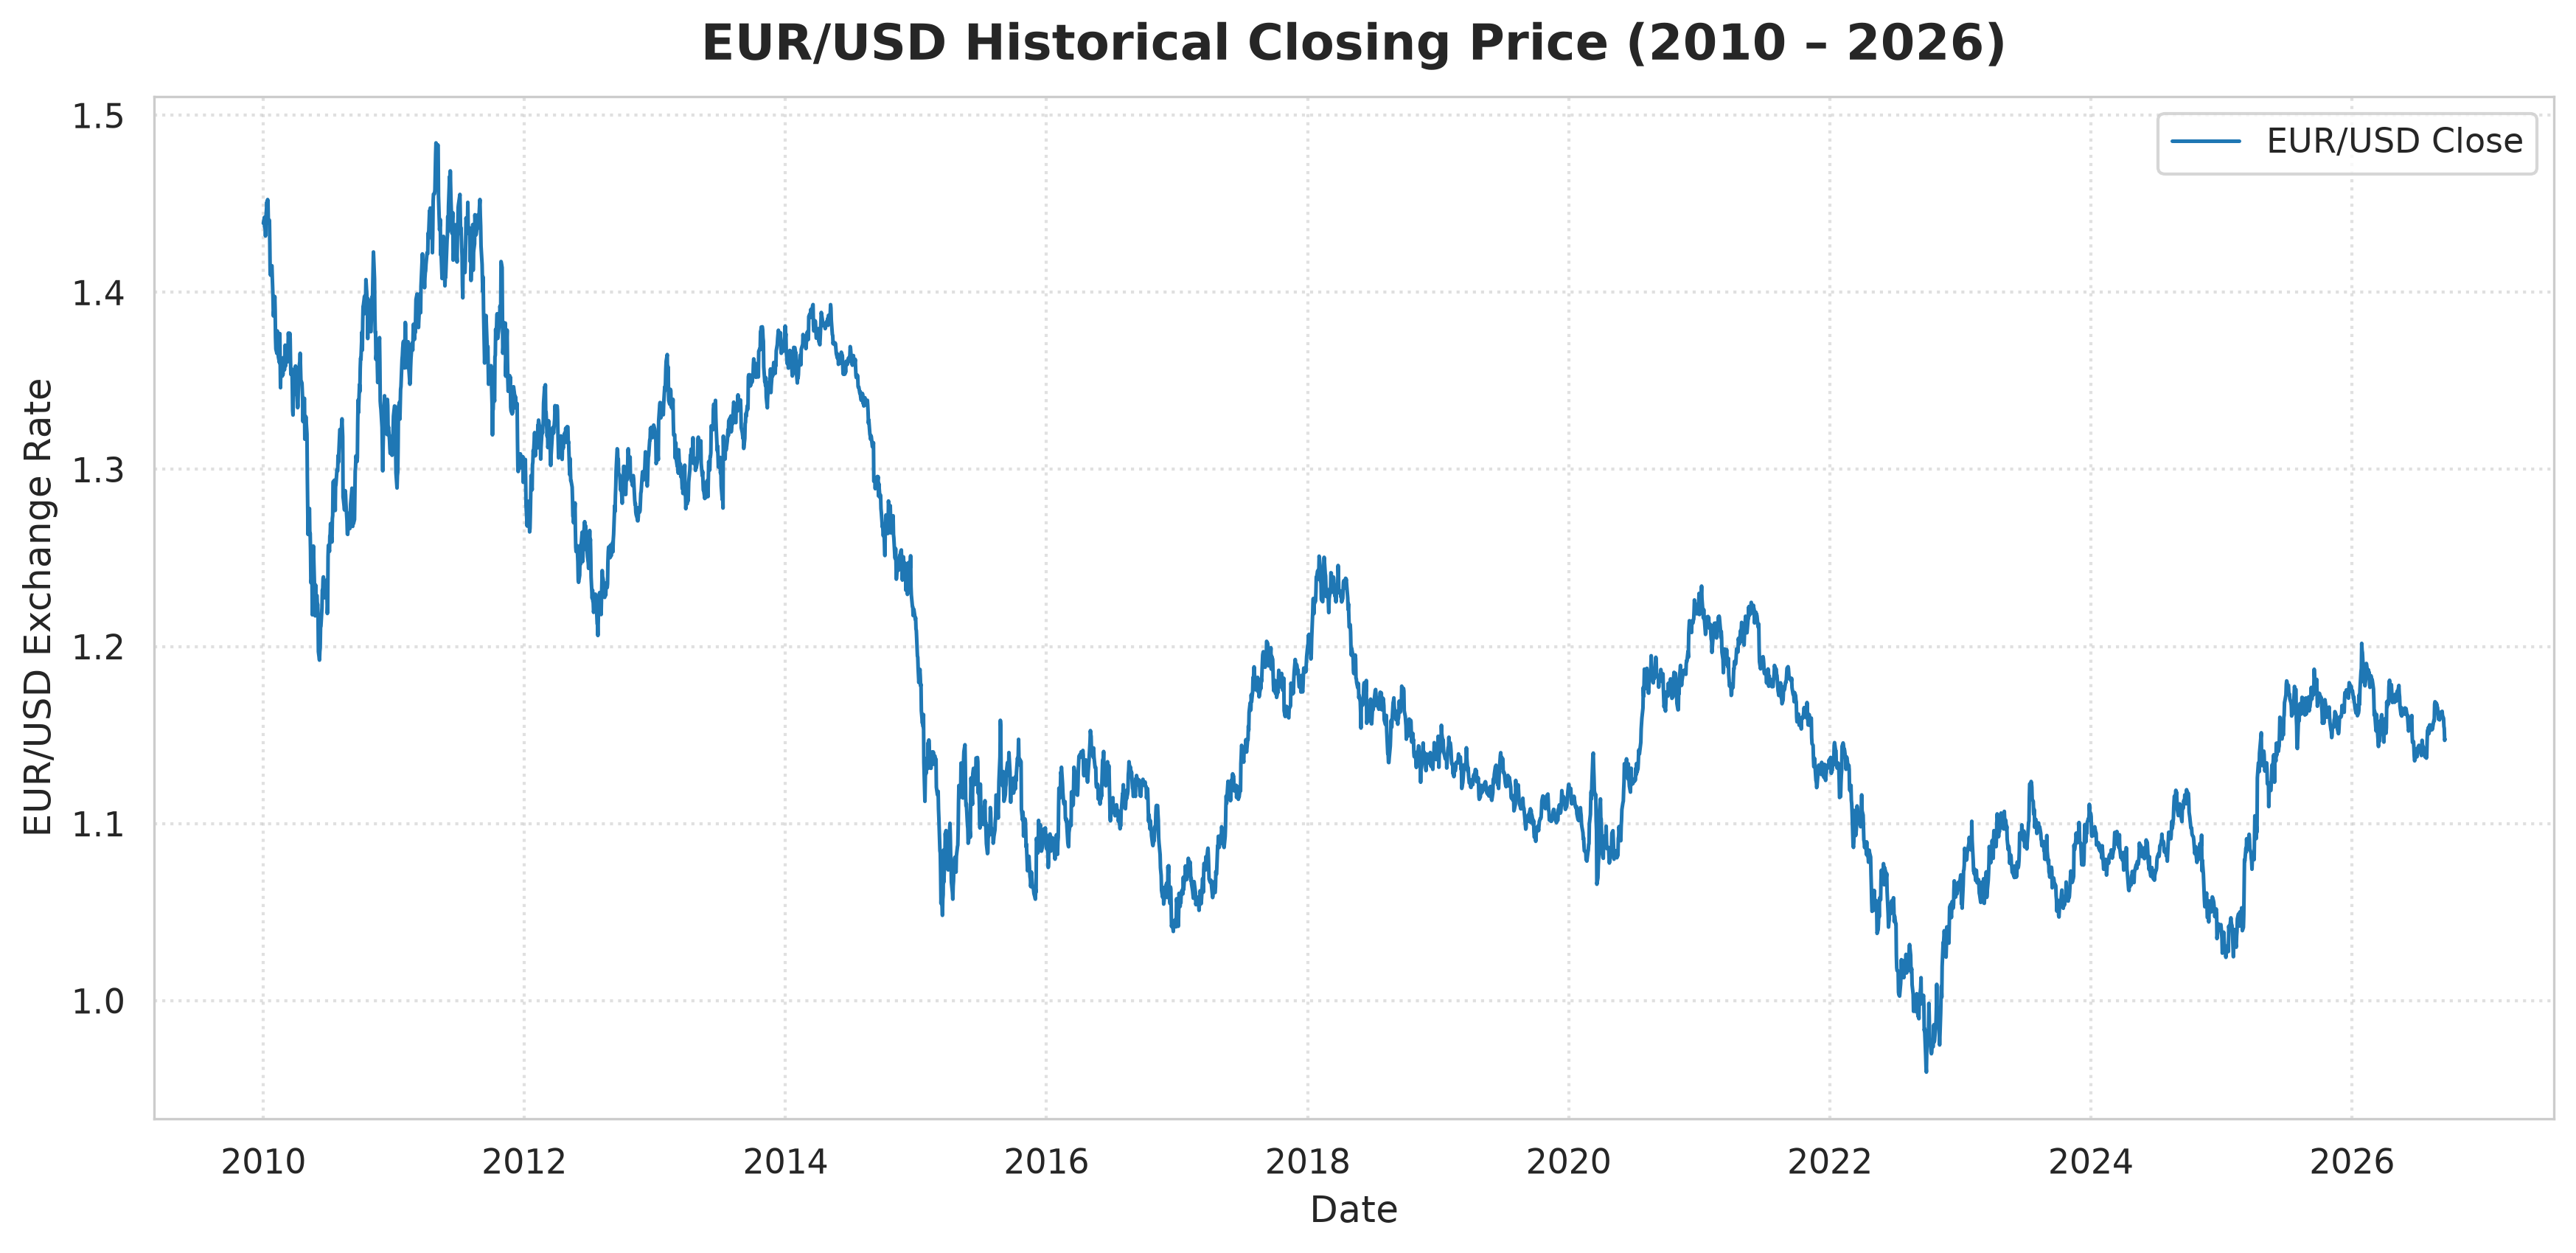

In [4]:
out_plots = 'EURUSD_Next_Day_Prediction/outputs/plots' if os.path.exists('EURUSD_Next_Day_Prediction') else '../outputs/plots'
plot_historical_close(df, output_dir=out_plots)
from IPython.display import Image
Image(filename=os.path.join(out_plots, '01_historical_close.png'))

## 5. Feature Engineering & Target Variable Creation
To prevent data leakage, features use only point-in-time past information $X_t$.  
The target variable is the **next trading day's Close price**: $Y_t = Close_{t+1}$ using `.shift(-1)`.

In [5]:
df_clean, feature_cols, target_col = prepare_dataset(df)
display(df_clean[feature_cols + [target_col]].head())

Feature engineering completed:
- Total rows before cleaning: 4351
- Total rows after cleaning NaNs: 4301
- Number of features: 19


,Open,High,Low,Close,Close_Lag1,Close_Lag2,Close_Lag3,Close_Lag5,Close_Lag10,SMA_5,SMA_10,SMA_20,SMA_50,EMA_10,EMA_20,Volatility_10,Volatility_20,High_Low_Range,Open_Close_Range,Target
Date,,,,,,,,,,,,,,,,,,,,
2010-03-11,1.364927,1.368794,1.362305,1.368532,1.364331,1.360692,1.361693,1.358400,1.353601,1.363629,1.362809,1.360906,1.392265,1.363186,1.366205,0.004939,0.006527,0.006489,0.003605,1.376993
2010-03-12,1.368495,1.379405,1.367353,1.376993,1.368532,1.364331,1.360692,1.362899,1.363104,1.366448,1.364198,1.361581,1.391025,1.365697,1.367232,0.004834,0.006612,0.012052,0.008499,1.367746
2010-03-15,1.377391,1.377391,1.364592,1.367746,1.376993,1.368532,1.364331,1.361693,1.356208,1.367659,1.365351,1.361953,1.389532,1.366069,1.367281,0.005089,0.006782,0.012800,-0.009646,1.376879
2010-03-16,1.367372,1.378284,1.366102,1.376879,1.367746,1.376993,1.368532,1.360692,1.362064,1.370896,1.366833,1.361962,1.388338,1.368035,1.368195,0.005316,0.006391,0.012182,0.009508,1.373834
2010-03-17,1.376898,1.381654,1.373098,1.373834,1.376879,1.367746,1.376993,1.364331,1.370163,1.372797,1.367200,1.362619,1.387006,1.369089,1.368732,0.005111,0.005801,0.008556,-0.003065,1.361396


## 6. Chronological 80/20 Train-Test Split
Financial data must **never** be randomly shuffled. We split chronologically into the first 80% (Training) and final 20% (Testing).


Chronological Train-Test Split Summary:
- Total Samples: 4301
- Training Samples: 3440 (2010-03-11 to 2023-05-24)
- Testing Samples:  861 (2023-05-25 to 2026-09-17)
Saved plot: ../outputs/plots\02_train_test_split.png


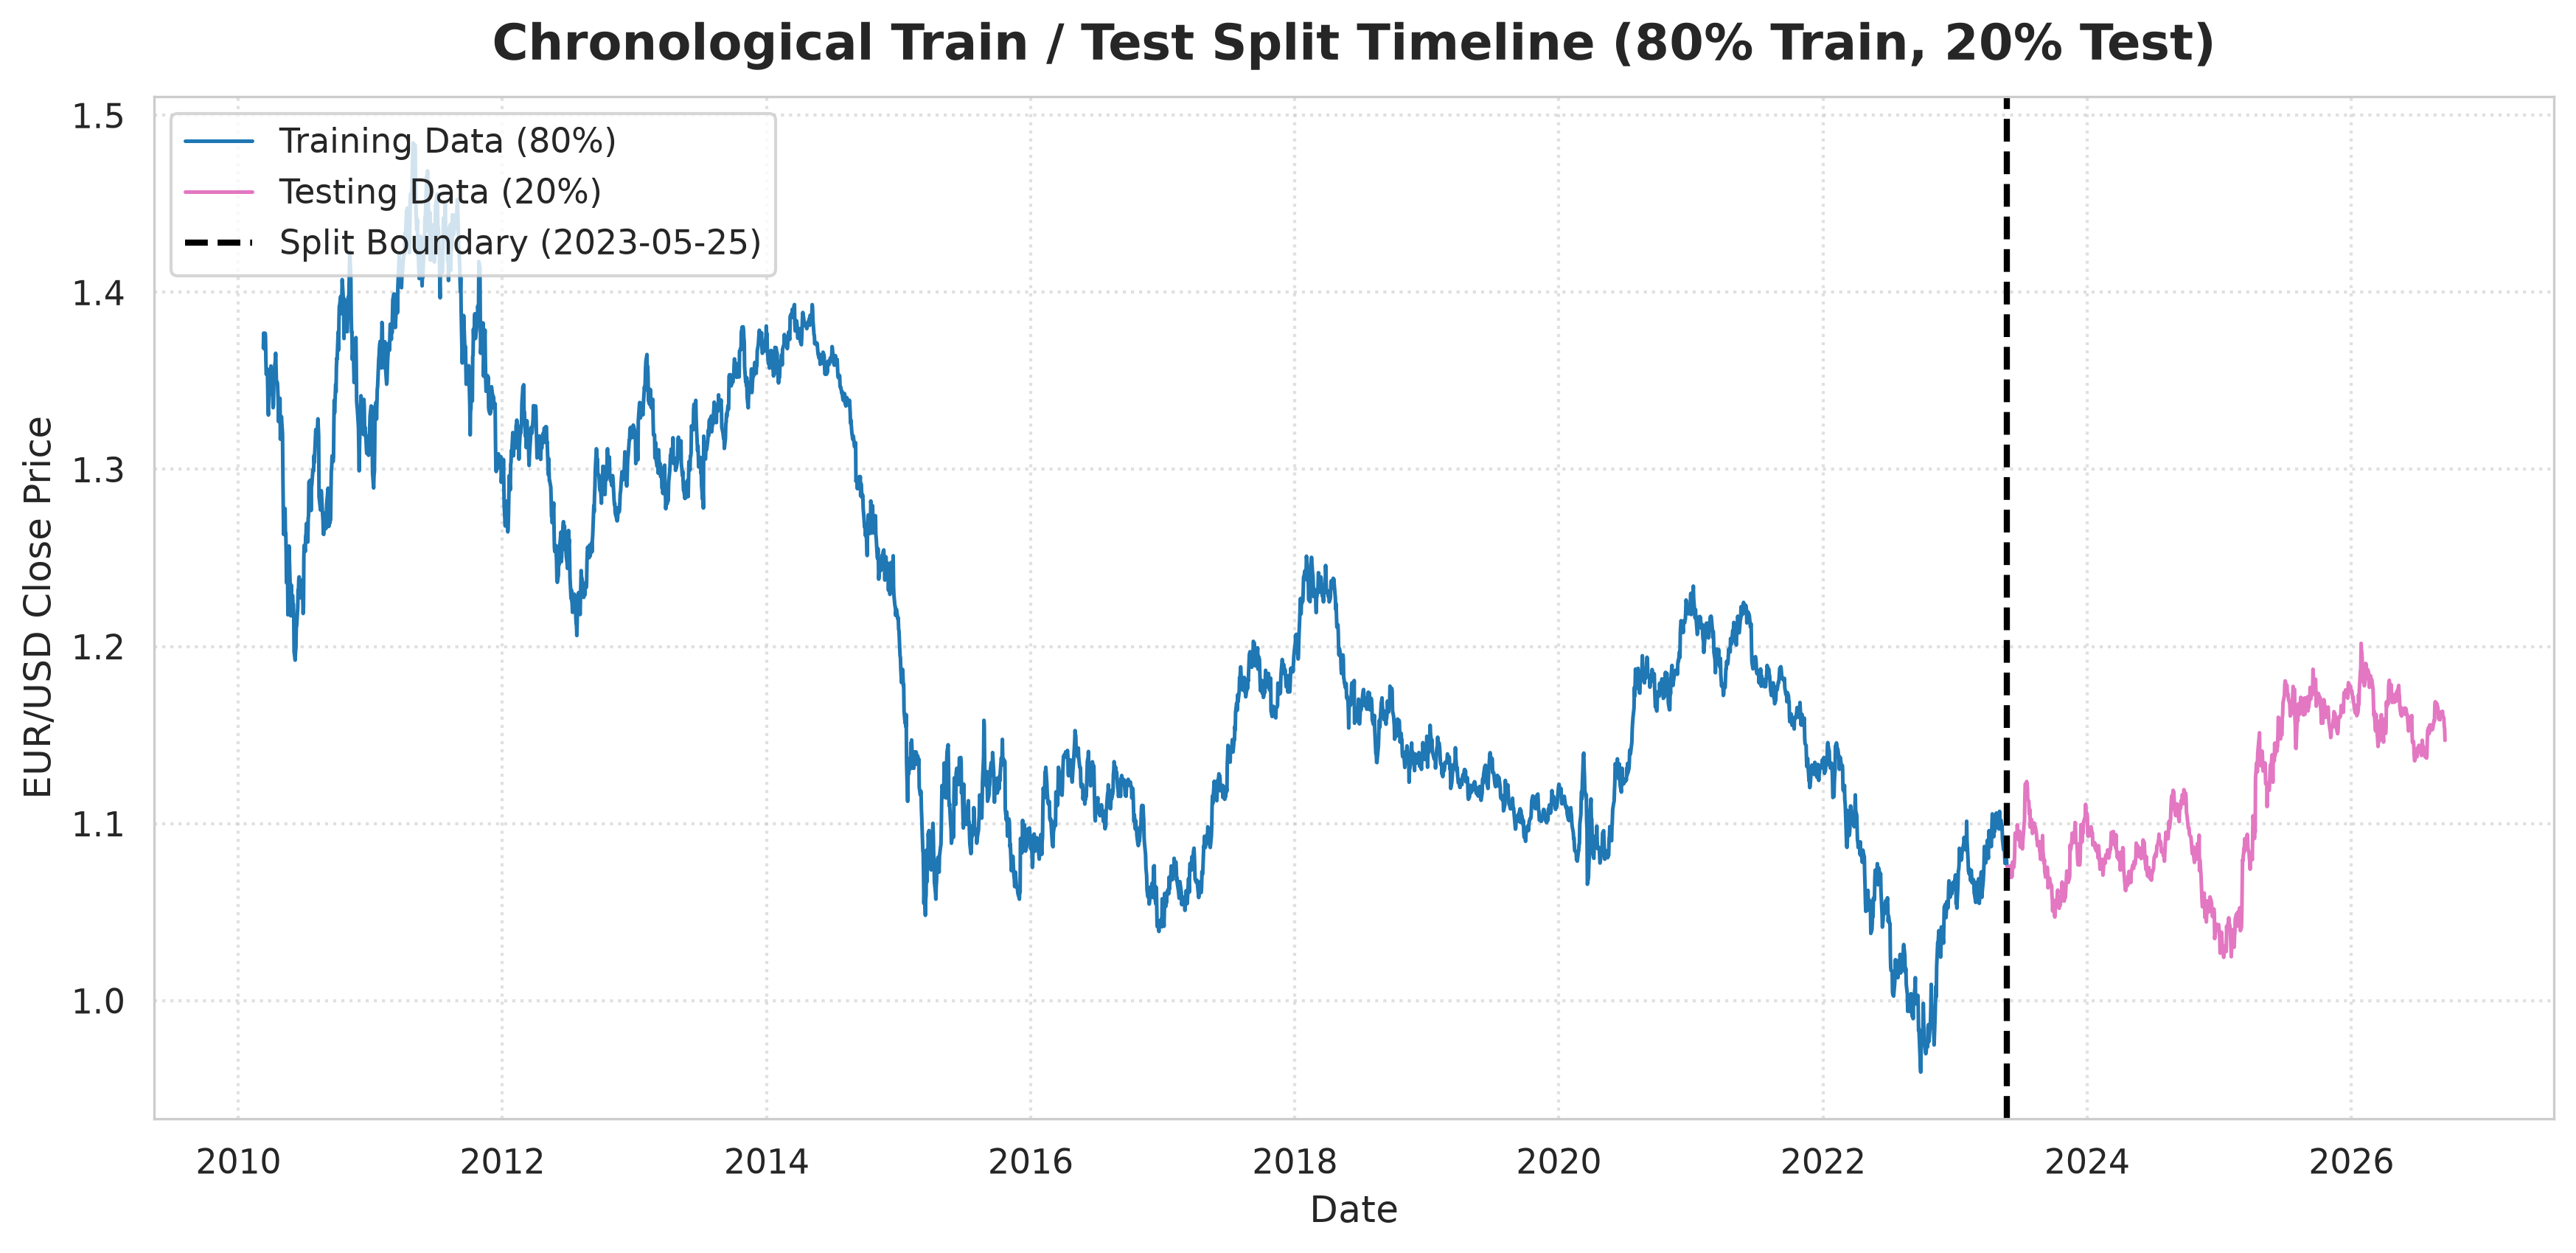

In [6]:
X_train, y_train, X_test, y_test, train_df, test_df = split_data_chronological(
    df_clean, feature_cols, target_col, train_pct=0.80
)
plot_train_test_split(train_df, test_df, output_dir=out_plots)
Image(filename=os.path.join(out_plots, '02_train_test_split.png'))

## 7. Model Training: Simple & Multiple Linear Regression

In [7]:
# A. Simple Linear Regression (Close_t -> Close_{t+1})
simple_model, simple_slope, simple_intercept = train_simple_linear_regression(X_train, y_train)
simple_r2 = simple_model.score(X_train[["Close"]], y_train)

# B. Multiple Linear Regression (Raw)
raw_model = train_raw_linear_regression(X_train, y_train)

# C. Standardized Multiple Linear Regression Pipeline
std_pipeline = train_standardized_linear_regression(X_train, y_train)

print(f"Raw Multiple Regression Intercept (β₀): {raw_model.intercept_:.6f}")
print(f"Simple Regression Slope (β₁): {simple_slope:.6f}, Intercept (β₀): {simple_intercept:.6f}")

Raw Multiple Regression Intercept (β₀): 0.004516
Simple Regression Slope (β₁): 0.998072, Intercept (β₀): 0.002229


## 8. Simple Linear Regression Visualization
We plot the exact computed simple regression line $\hat{Y} = \beta_0 + \beta_1 X$.

findfont: Failed to find font weight medium, now using 400.


Saved plot: ../outputs/plots\05_simple_regression_scatter.png
Saved plot: ../outputs/plots\06_simple_regression_equation.png


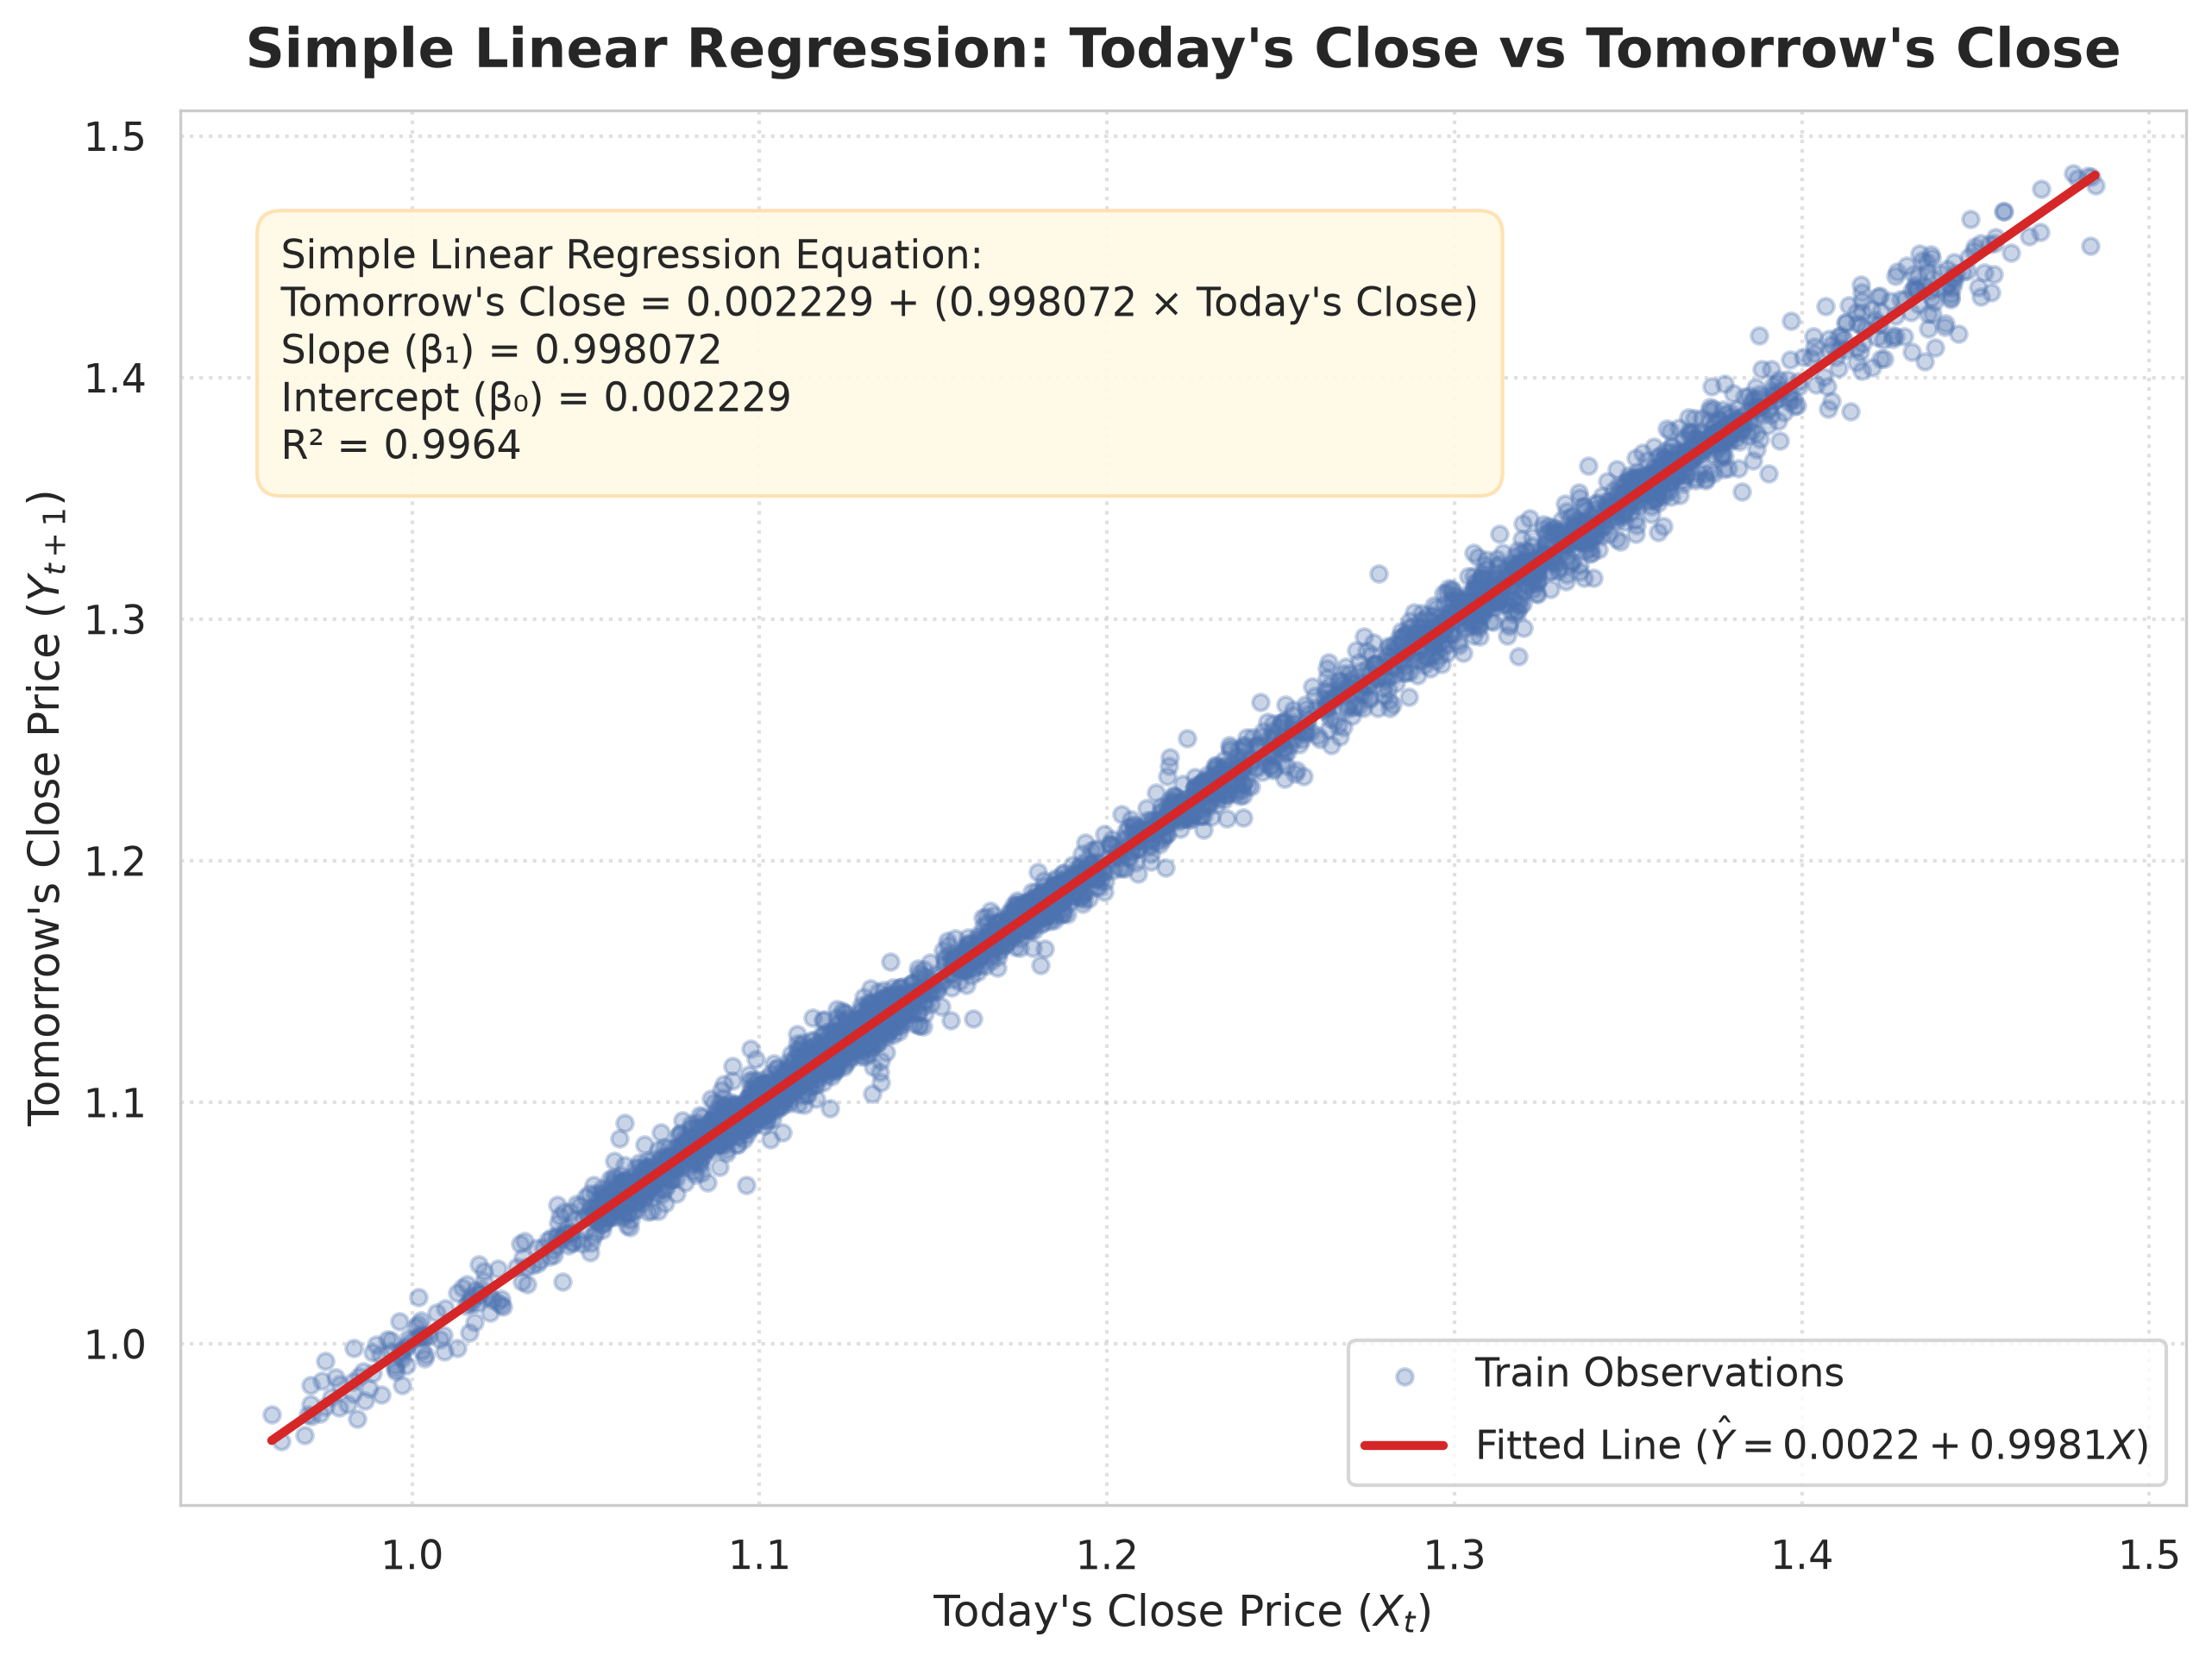

In [8]:
plot_simple_regression(X_train, y_train, simple_slope, simple_intercept, simple_r2, output_dir=out_plots)
Image(filename=os.path.join(out_plots, '05_simple_regression_scatter.png'))

## 9. Feature Coefficients: Raw vs Standardized
Raw coefficients depend on feature scales. Standardized coefficients put all features on a 1-standard-deviation scale for direct comparison.

,Feature,Raw_Coefficient,Abs_Raw_Coef,Standardized_Coefficient,Abs_Std_Coef
1,High,0.799695,0.799695,0.069720,0.069720
2,Low,0.440304,0.440304,0.069676,0.069676
9,SMA_5,0.194616,0.194616,0.021832,0.021832
14,EMA_20,-0.171933,0.171933,-0.019186,0.019186
0,Open,-0.381191,0.381191,-0.017046,0.017046
3,Close,0.077791,0.077791,-0.017033,0.017033
13,EMA_10,0.133279,0.133279,0.014917,0.014917
5,Close_Lag2,-0.074759,0.074759,-0.008398,0.008398
17,High_Low_Range,0.359391,0.359391,0.005613,0.005613
11,SMA_20,0.046037,0.046037,0.005150,0.005150


Saved plot: ../outputs/plots\07_raw_coefficients.png
Saved plot: ../outputs/plots\08_standardized_coefficients.png


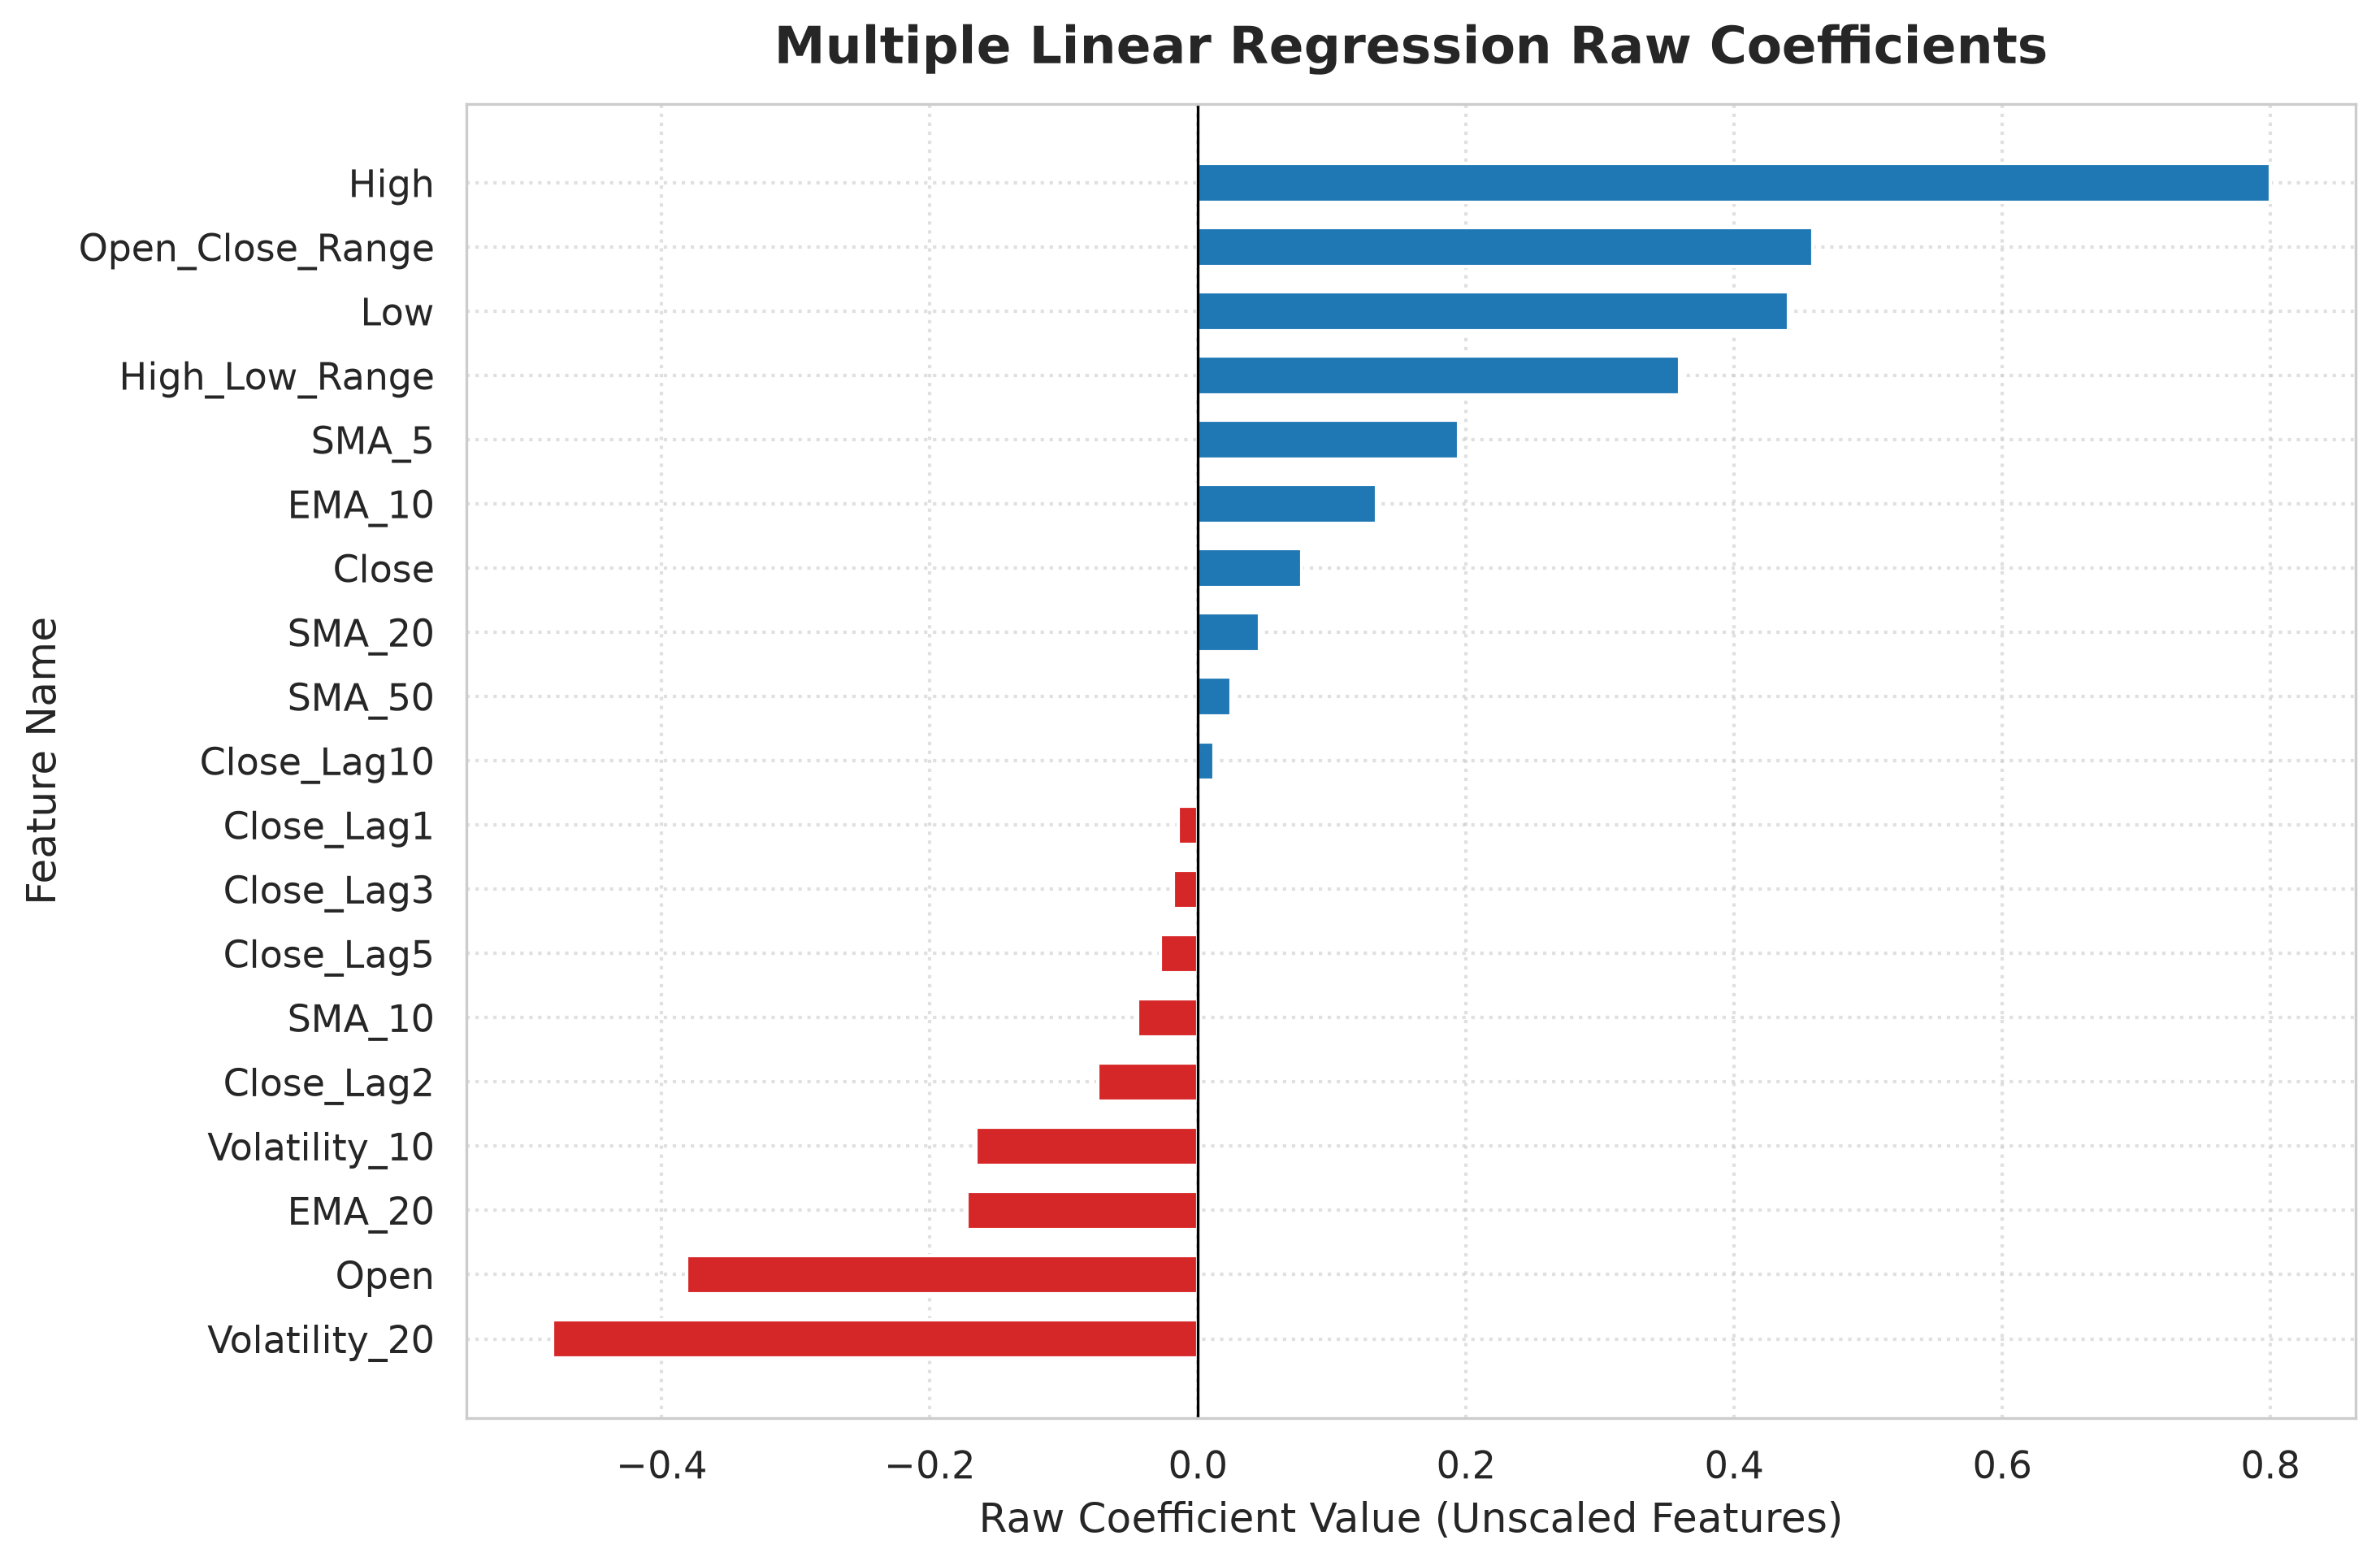

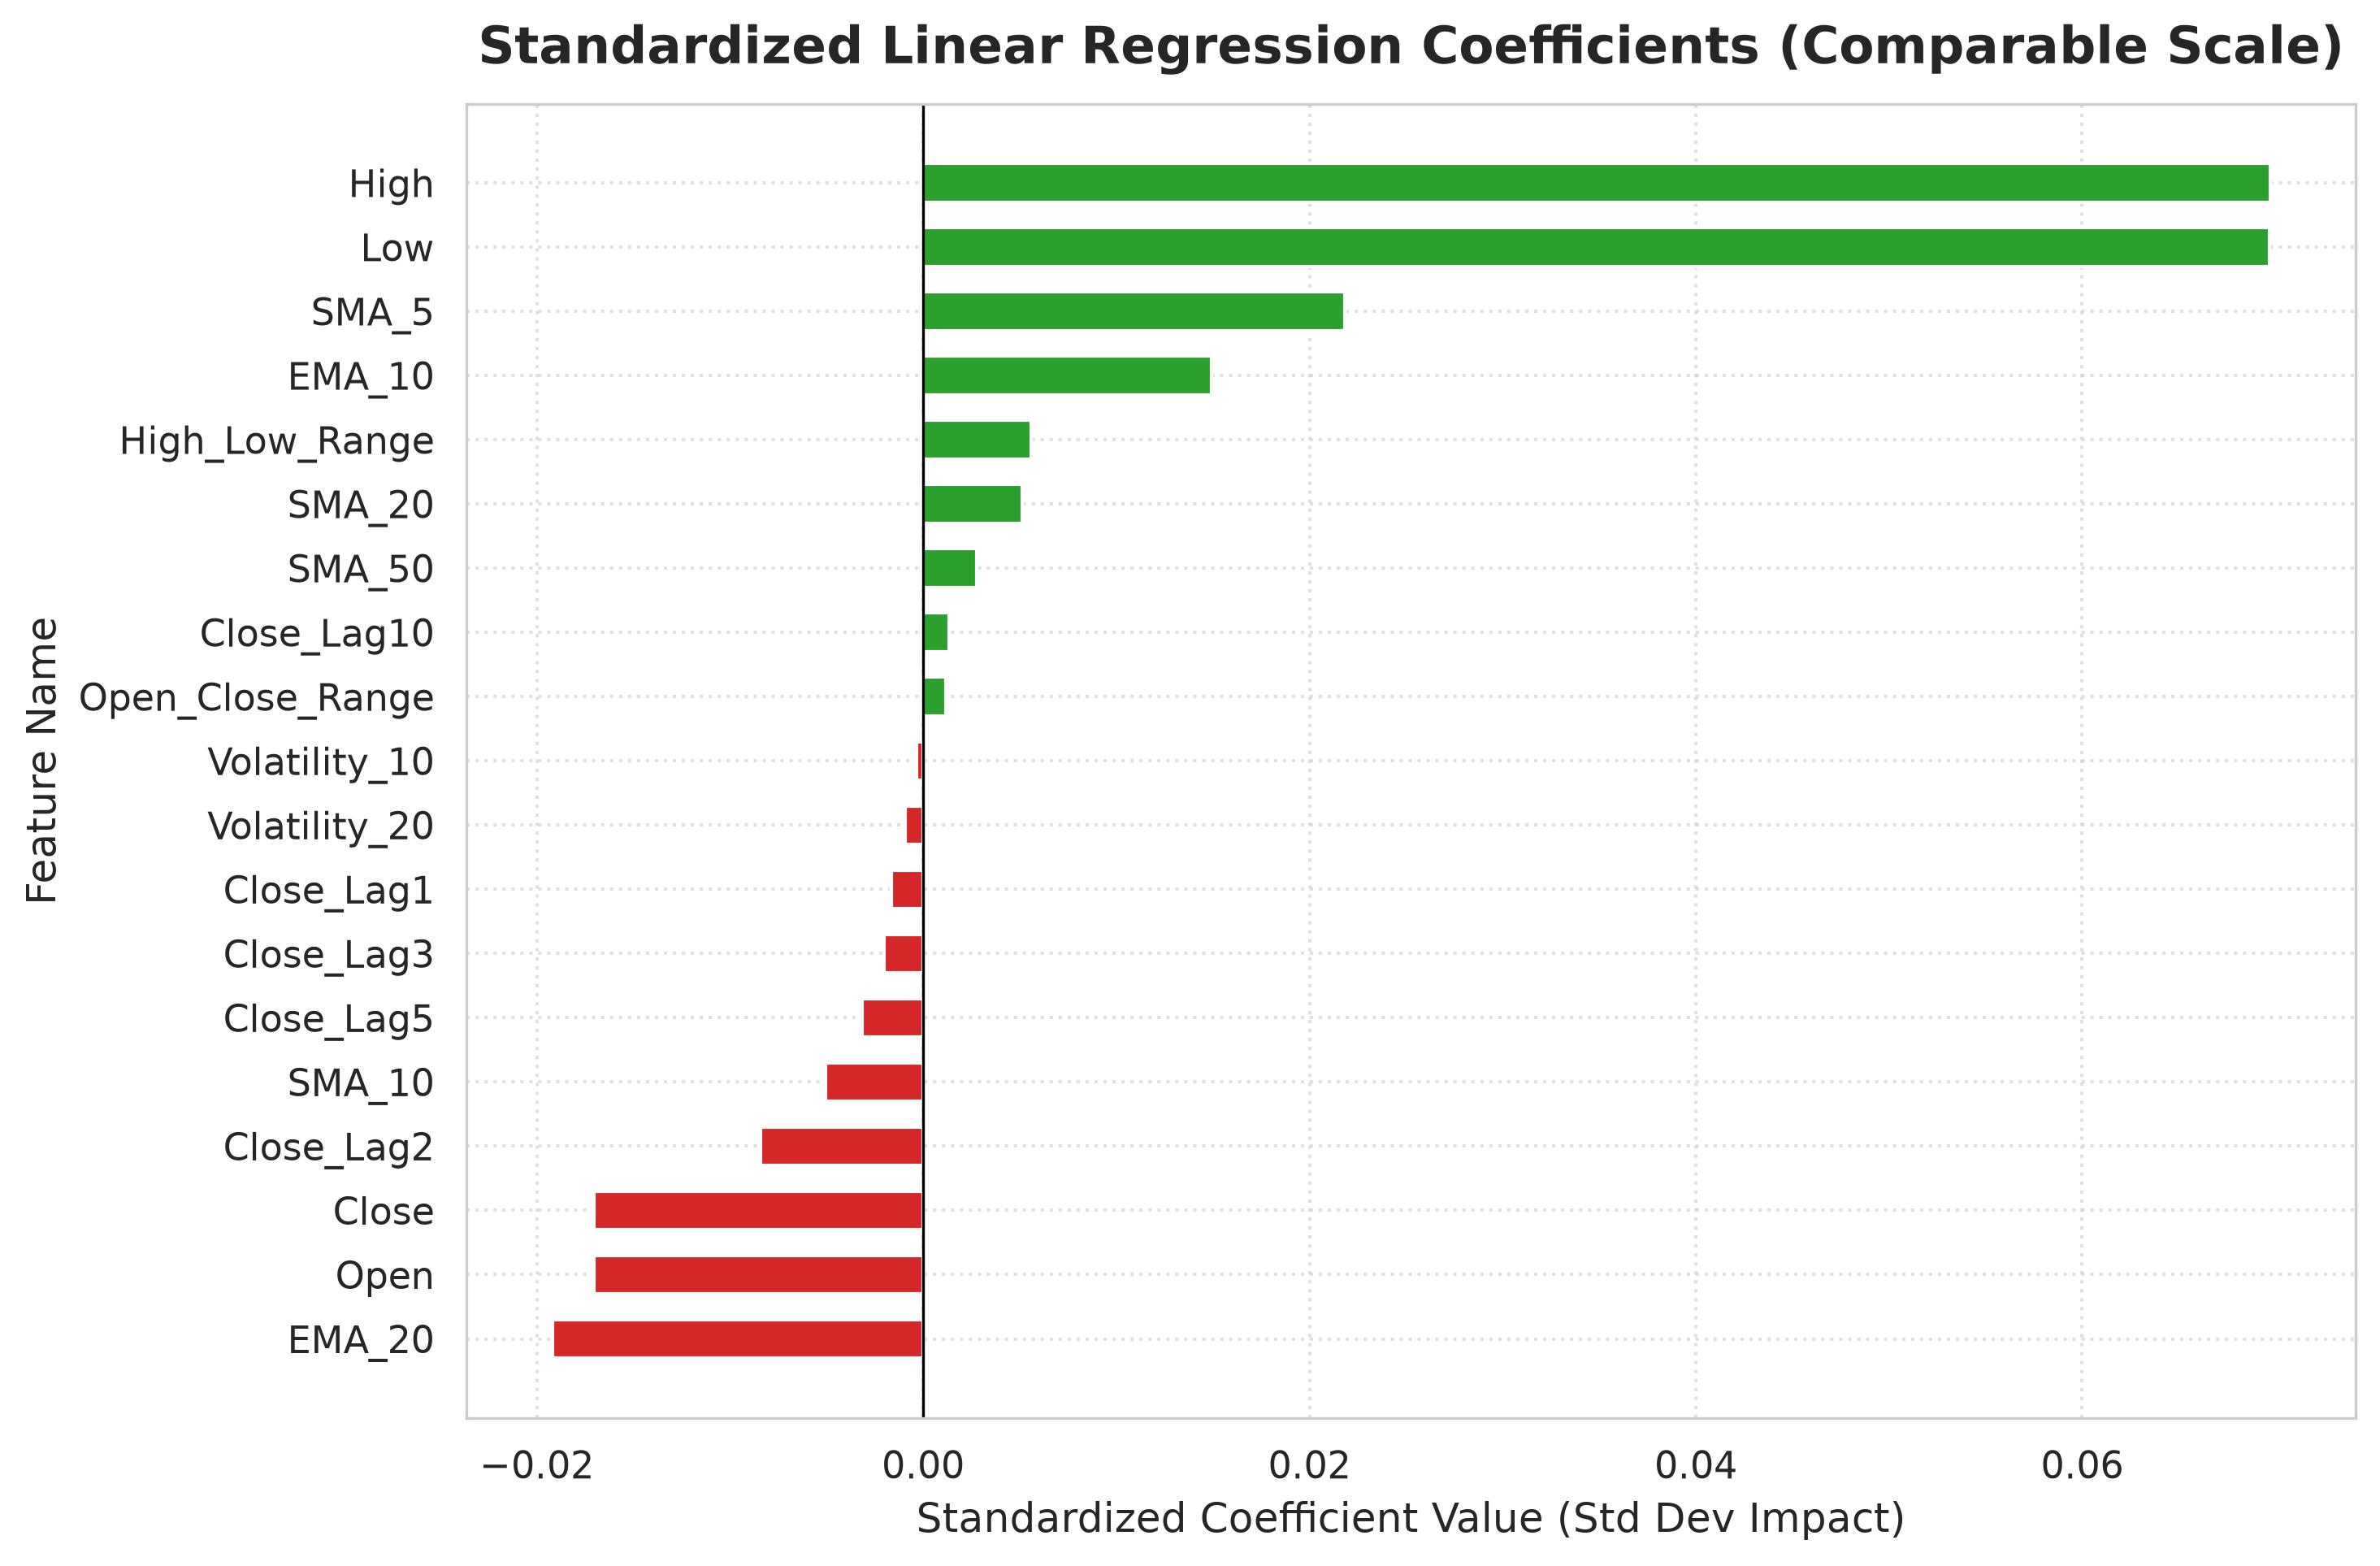

In [9]:
coef_df = extract_coefficients(feature_cols, raw_model, std_pipeline)
display(coef_df)

plot_raw_coefficients(coef_df, output_dir=out_plots)
plot_standardized_coefficients(coef_df, output_dir=out_plots)

display(Image(filename=os.path.join(out_plots, '07_raw_coefficients.png')))
display(Image(filename=os.path.join(out_plots, '08_standardized_coefficients.png')))

## 10. Test Set Predictions & Performance Evaluation

Saved plot: ../outputs/plots\03_actual_vs_predicted_timeline.png
Saved plot: ../outputs/plots\04_actual_vs_predicted_scatter.png


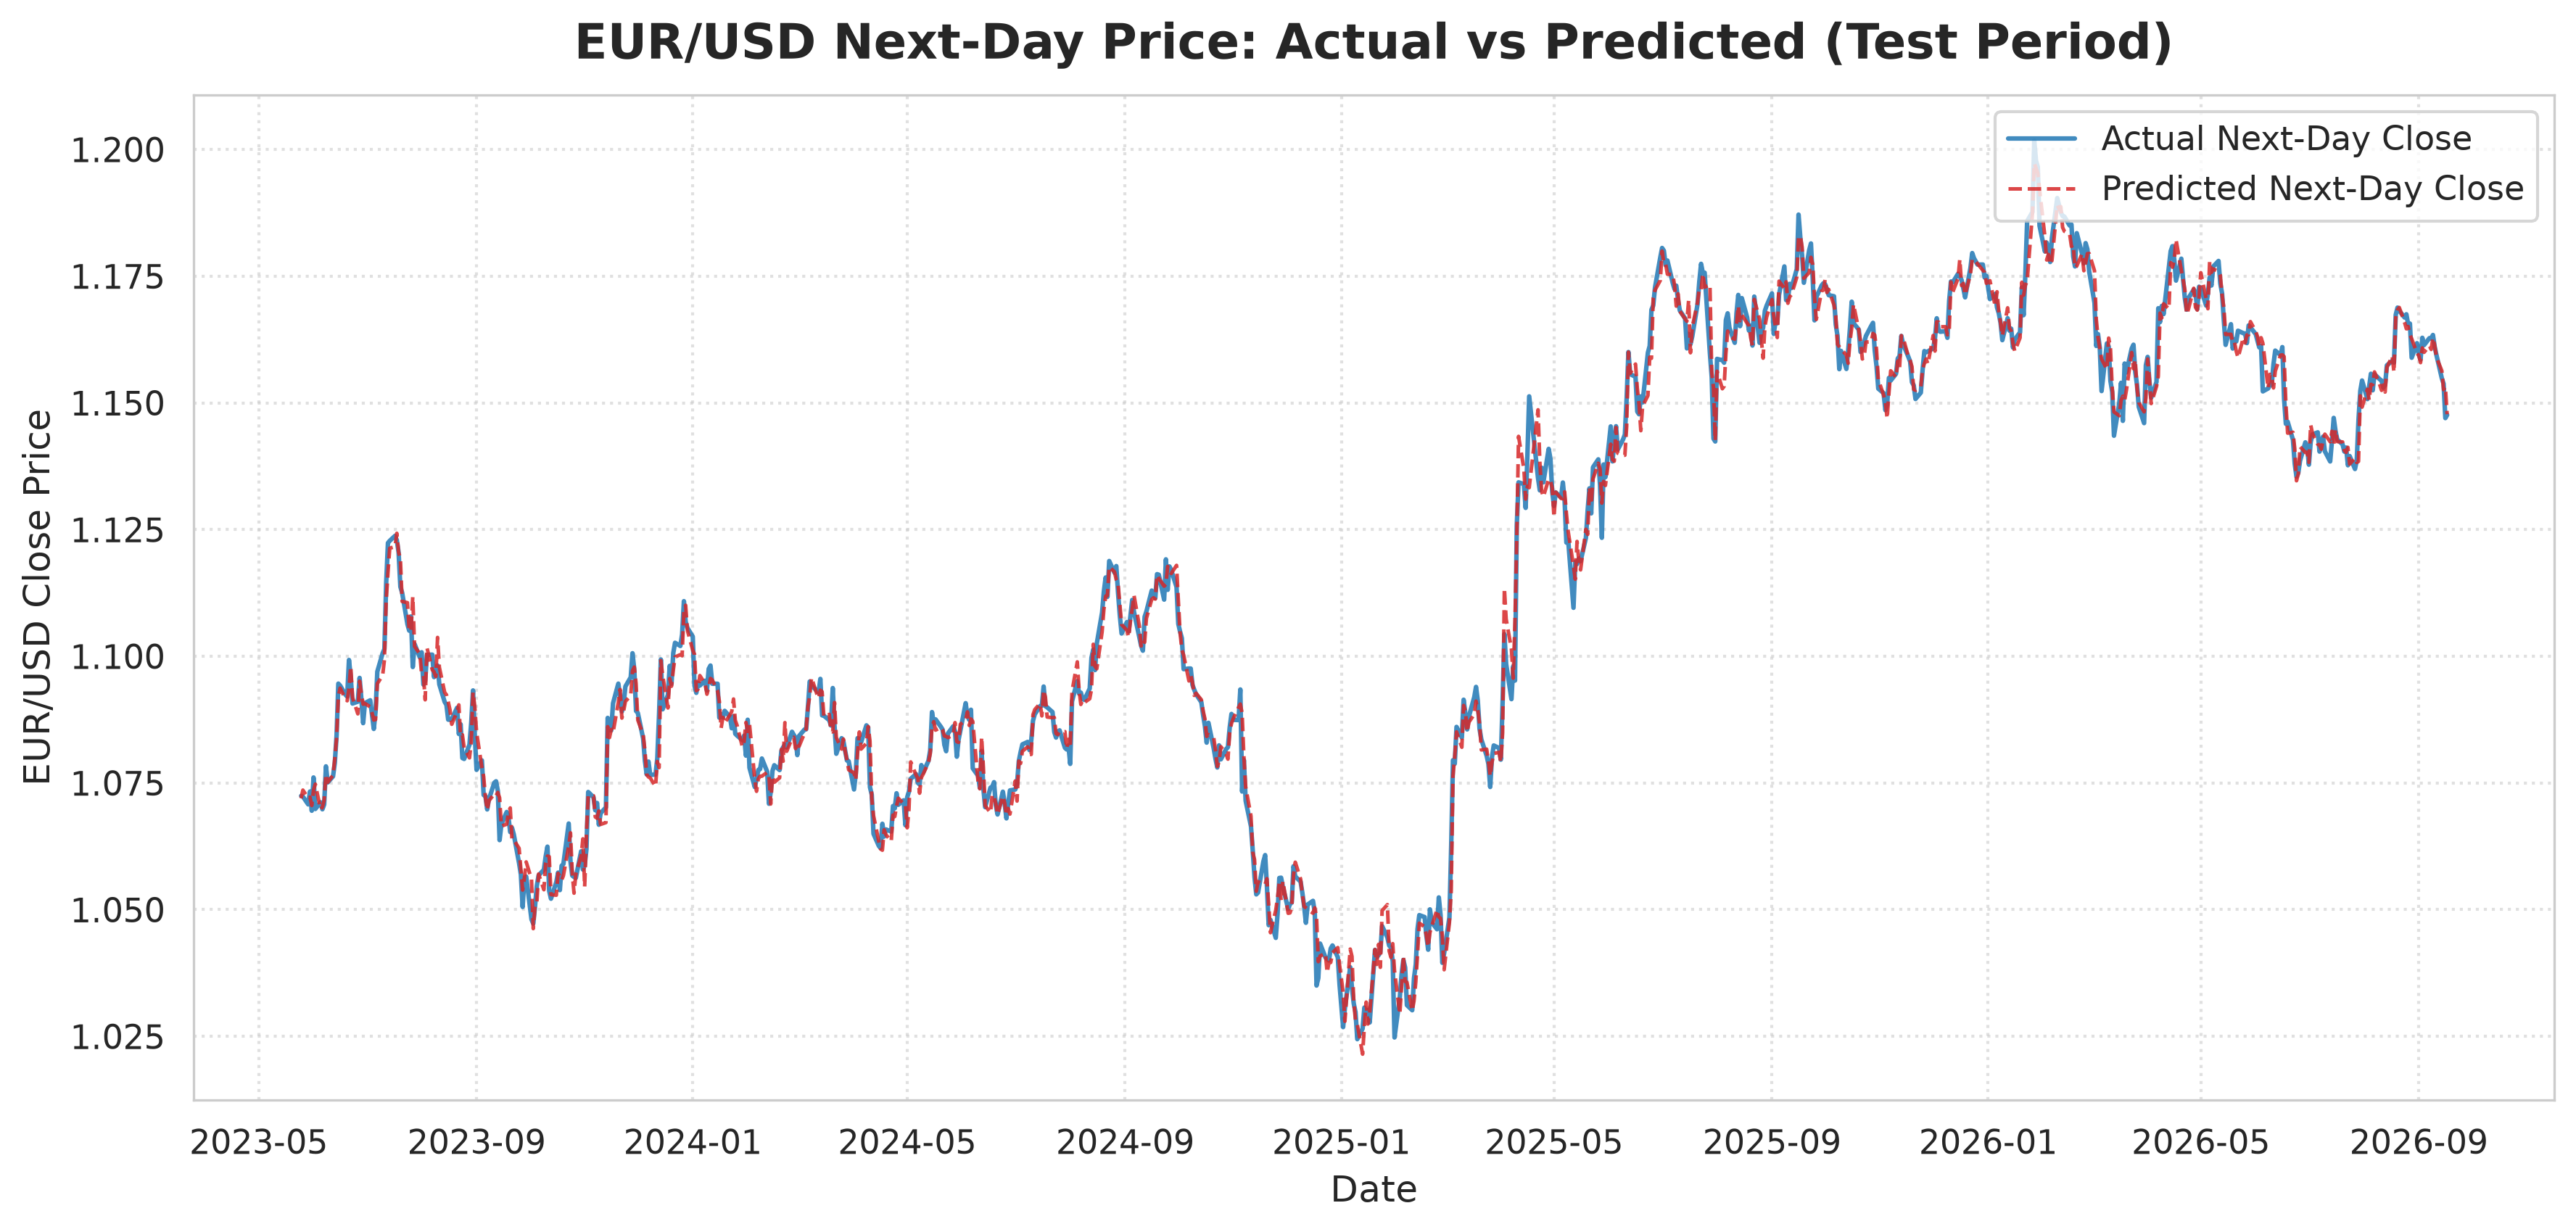

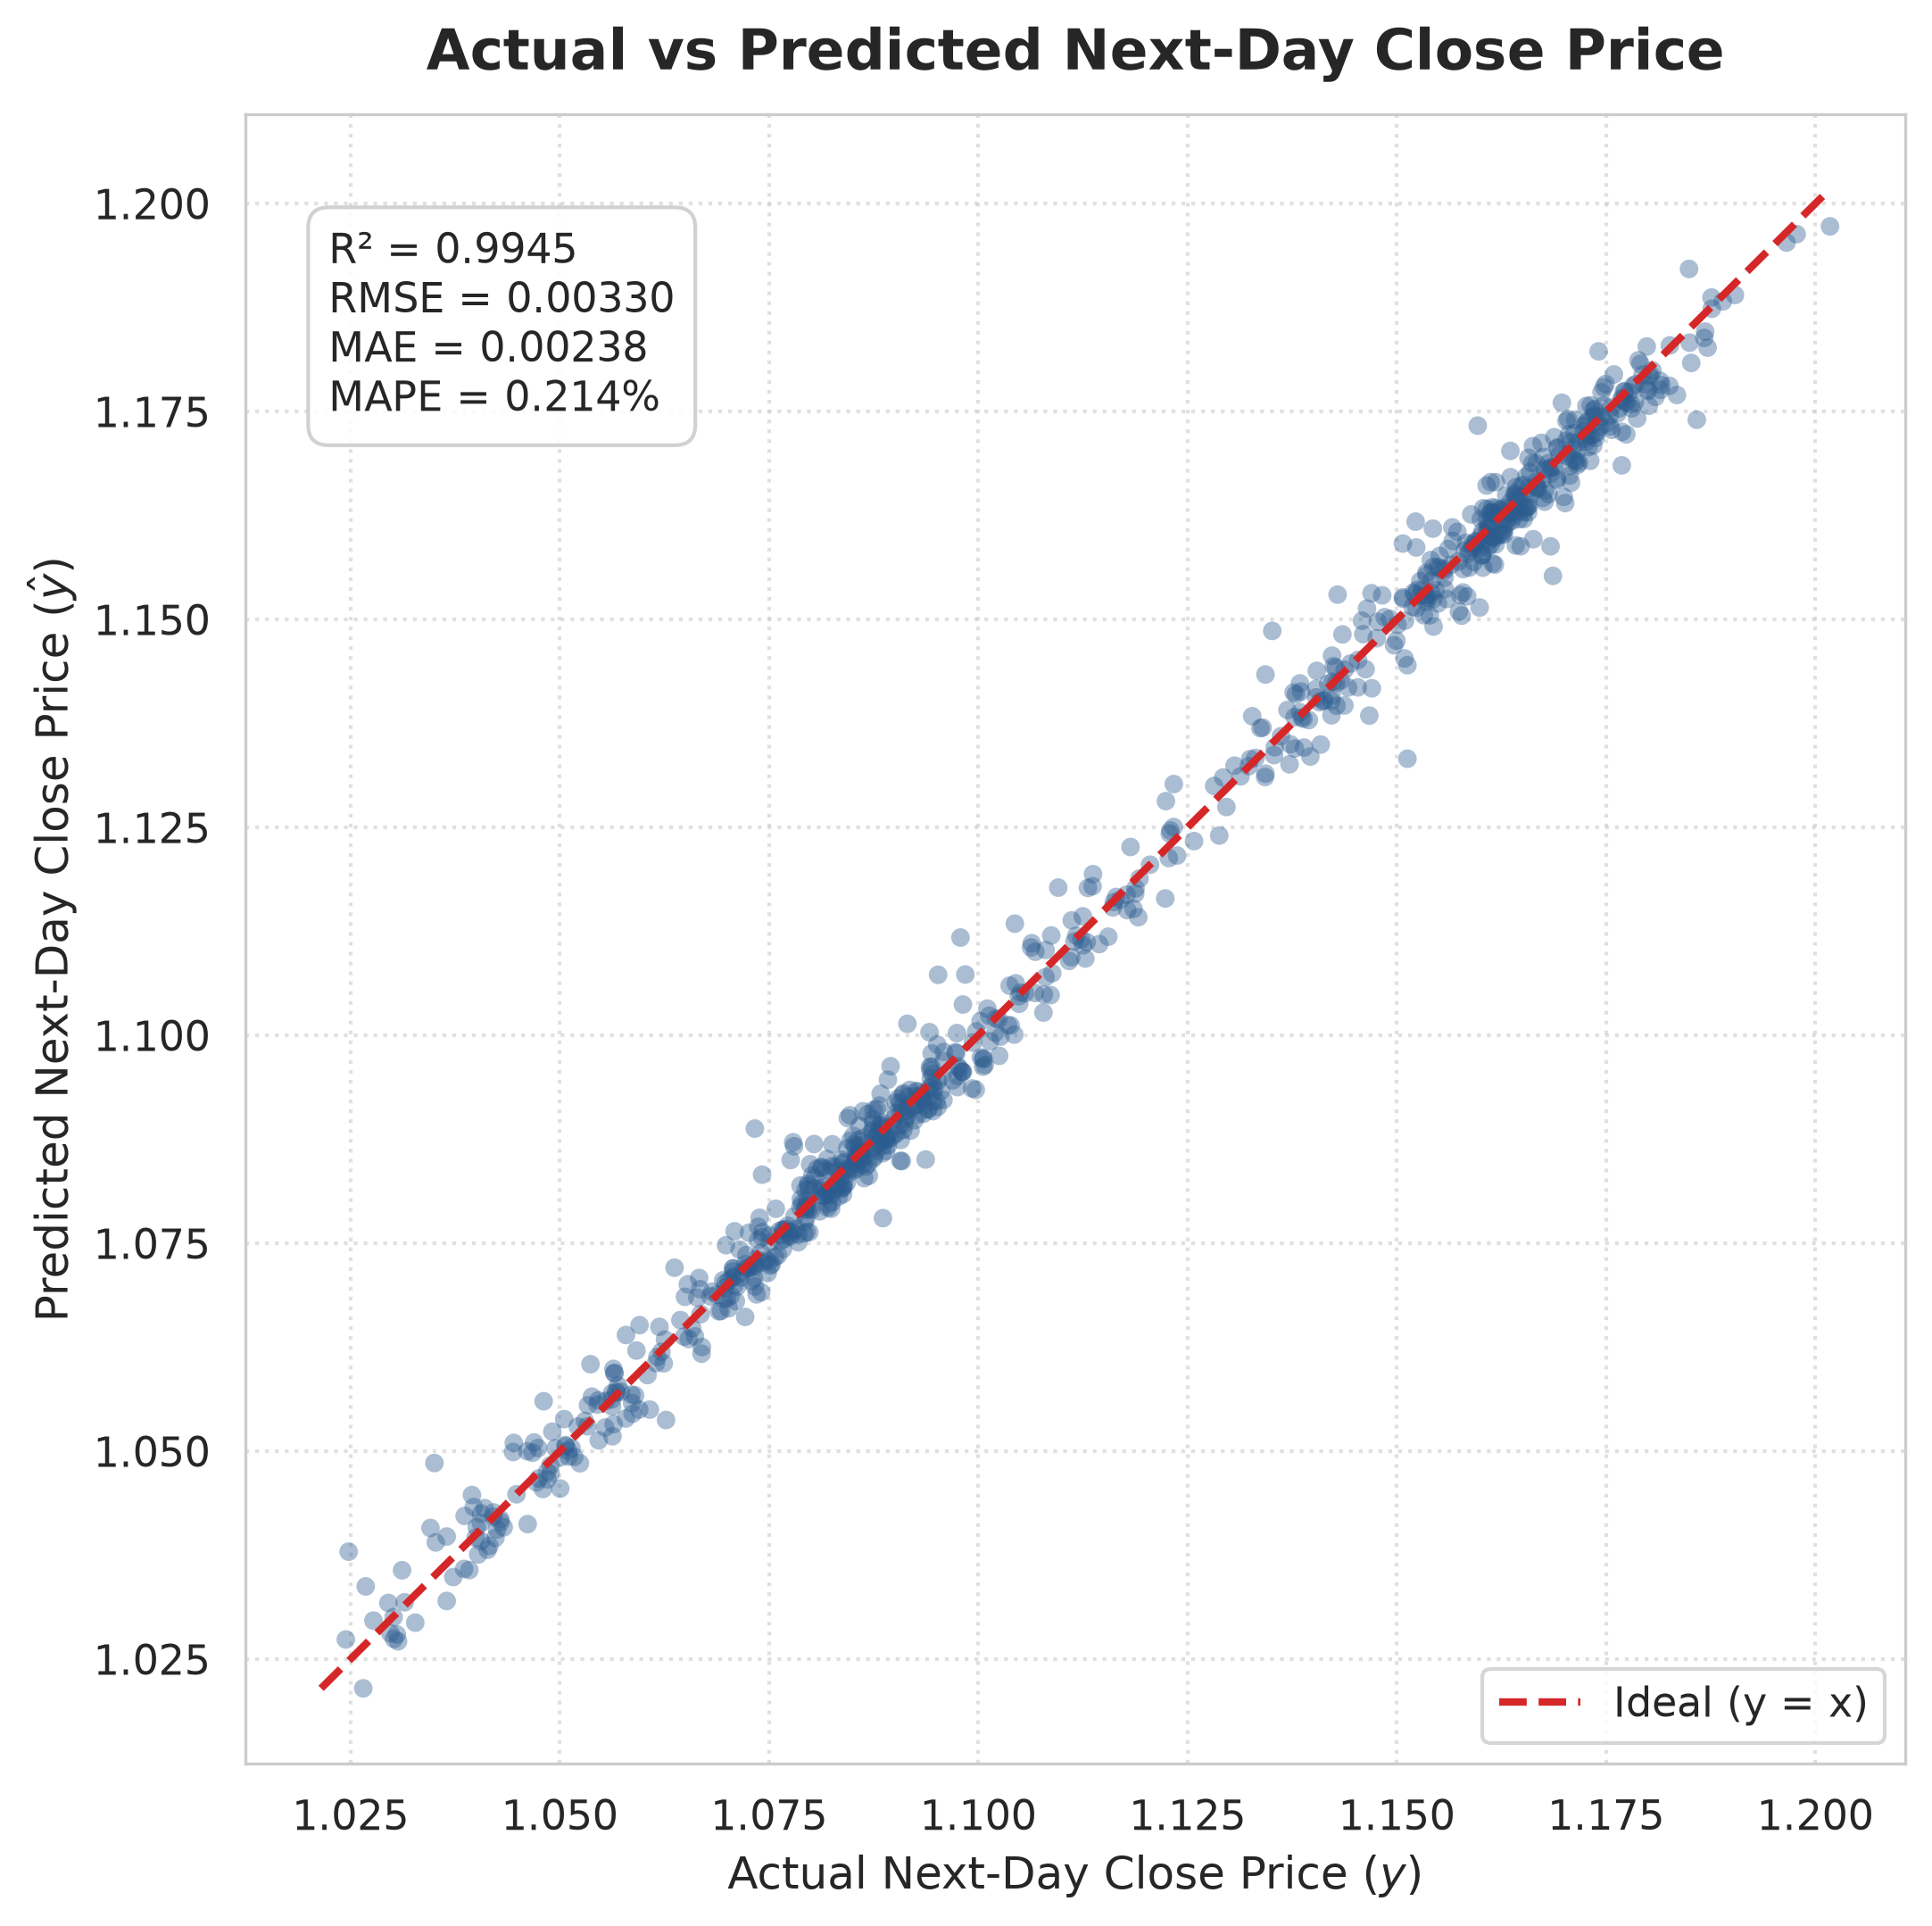

In [10]:
test_preds = std_pipeline.predict(X_test)
train_preds = std_pipeline.predict(X_train)

results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': test_preds,
    'Close_Today': X_test['Close'],
    'Error': y_test - test_preds,
    'Absolute_Error': np.abs(y_test - test_preds)
}, index=y_test.index)

train_metrics = evaluate_predictions(y_train, train_preds, price_today=X_train['Close'])
test_metrics = evaluate_predictions(y_test, test_preds, price_today=X_test['Close'])
baseline_metrics = evaluate_naive_baseline(X_test, y_test)

plot_actual_vs_predicted_timeline(results_df, output_dir=out_plots)
plot_actual_vs_predicted_scatter(results_df, test_metrics, output_dir=out_plots)

display(Image(filename=os.path.join(out_plots, '03_actual_vs_predicted_timeline.png')))
display(Image(filename=os.path.join(out_plots, '04_actual_vs_predicted_scatter.png')))

## 11. Naive Baseline Comparison
We compare the Linear Regression model against the **Naive Previous-Close Model** ($\hat{Y}_{t+1} = Close_t$).

c:\Users\Admin\Quants Test\EURUSD_Next_Day_Prediction_Project\EURUSD_Next_Day_Prediction\src\visualization.py:279: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved plot: ../outputs/plots\11_model_vs_baseline.png


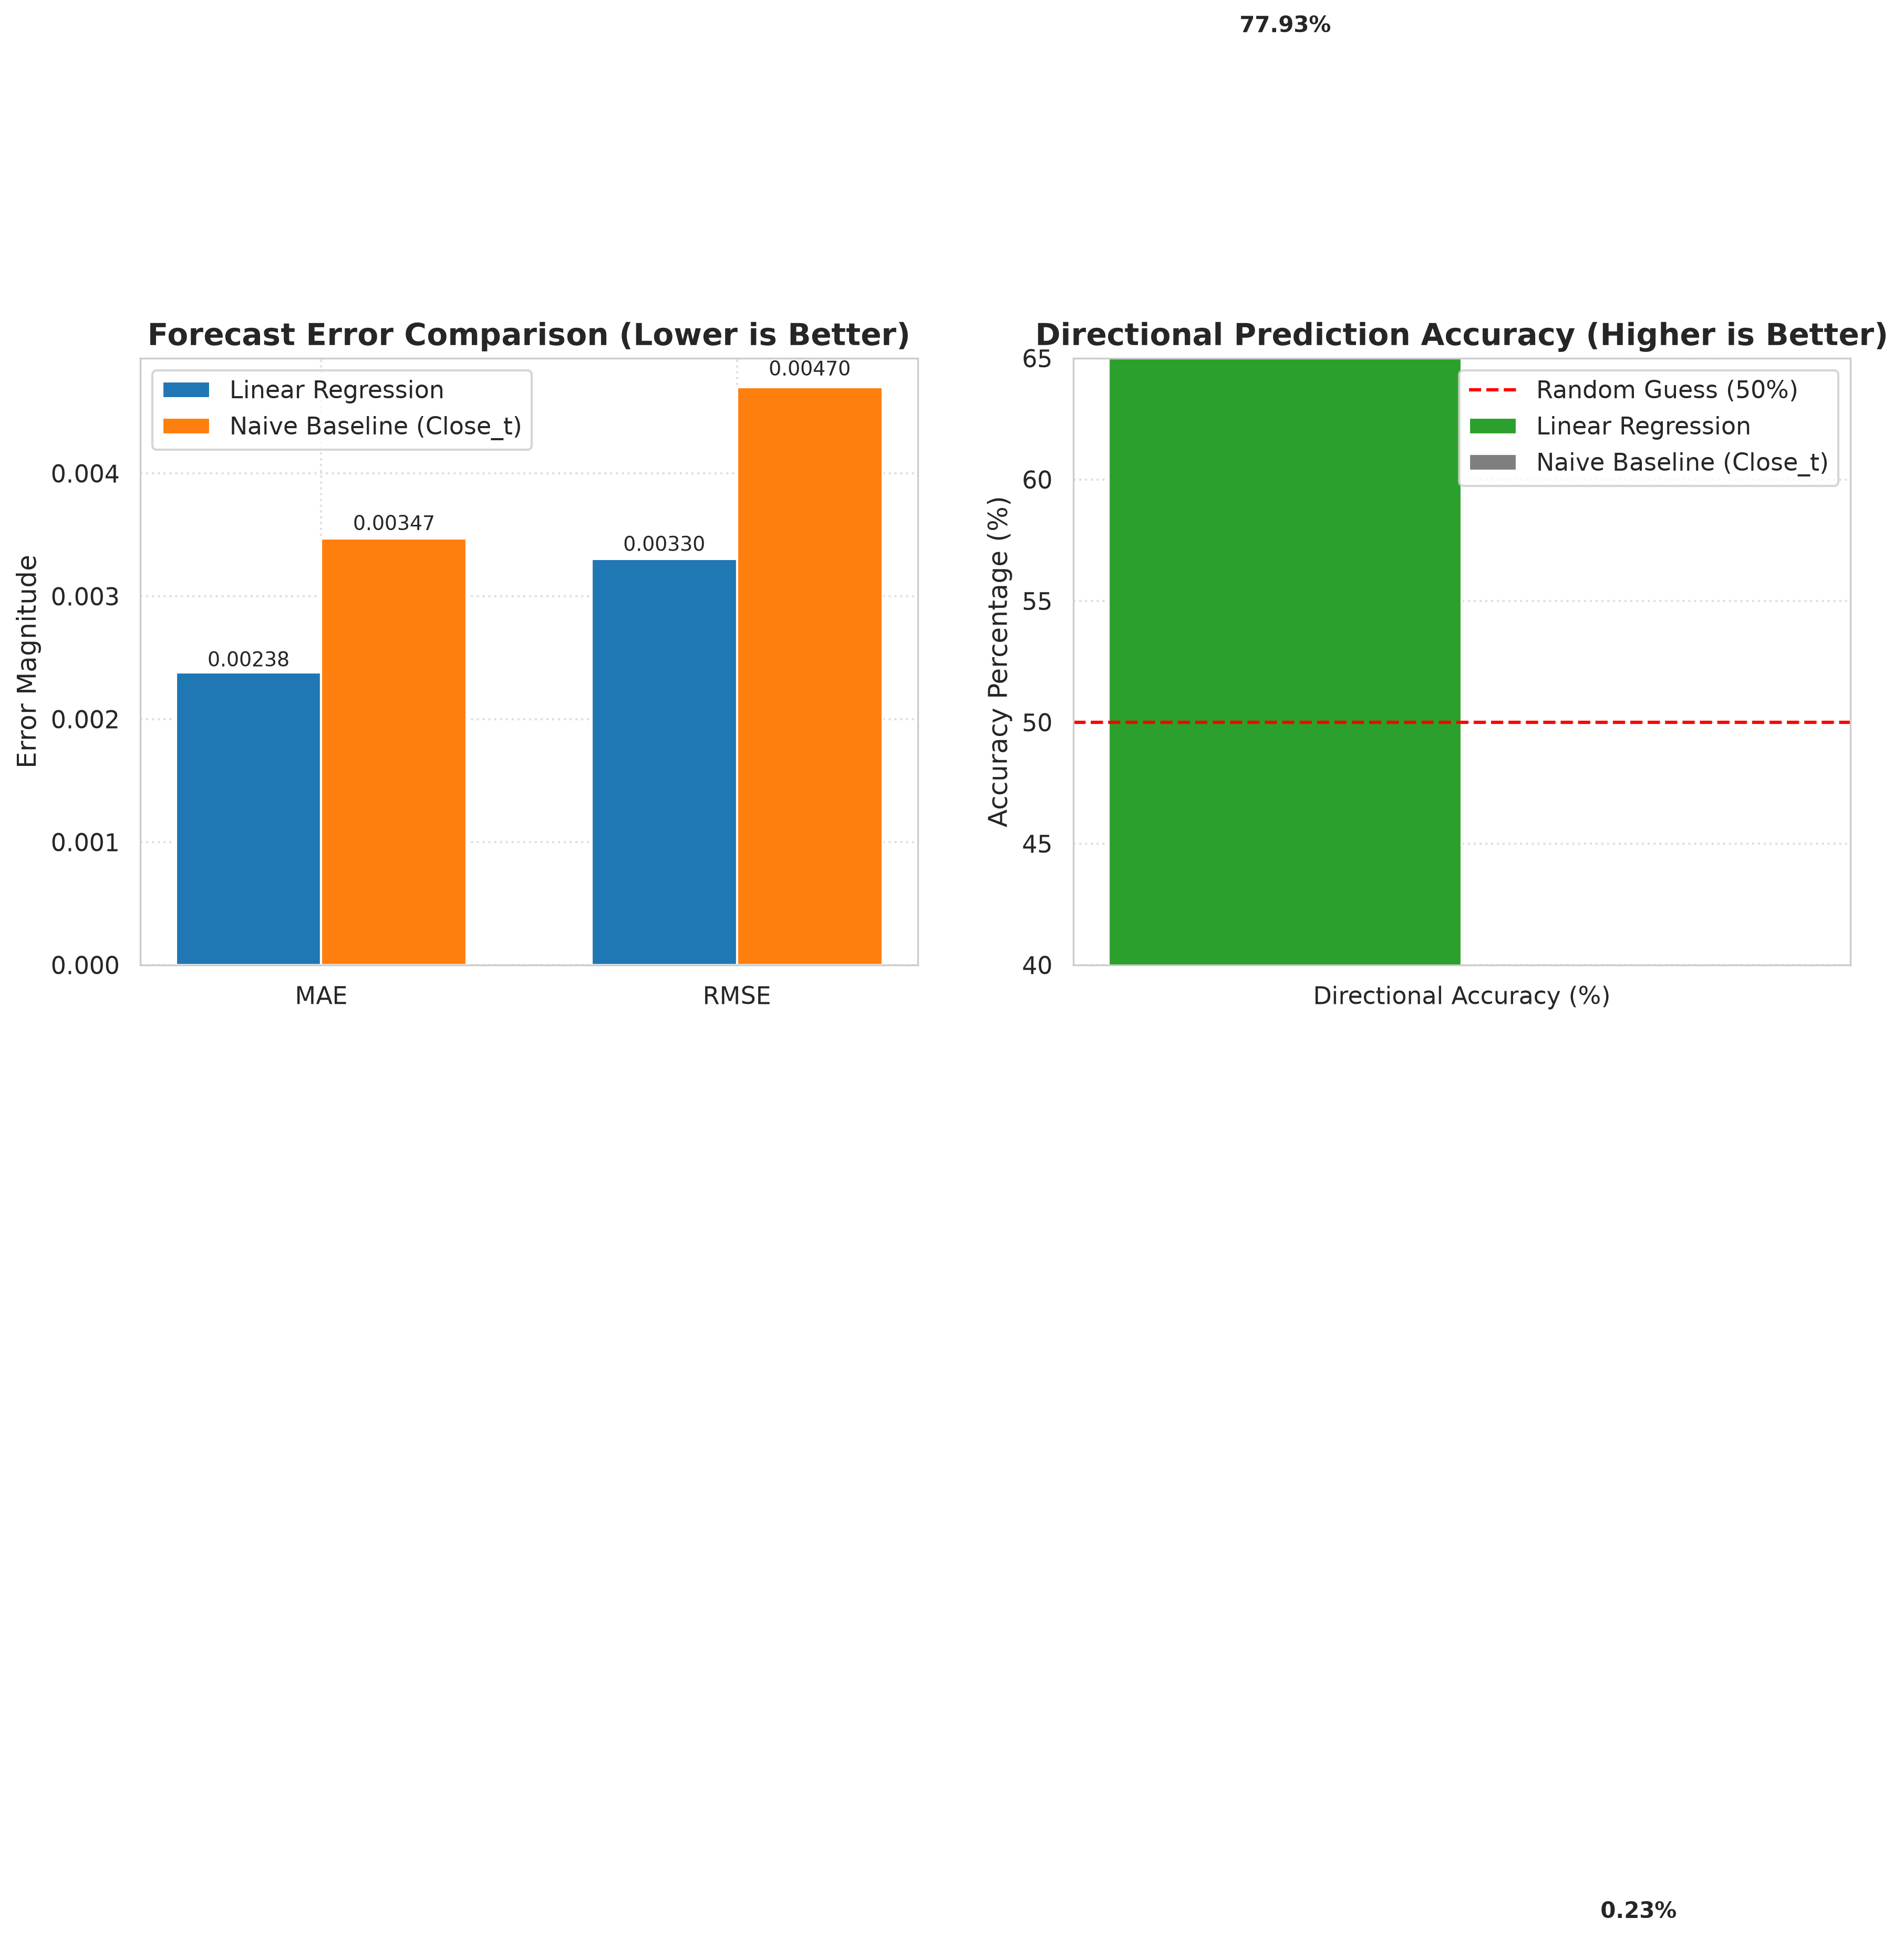

In [11]:
plot_model_vs_baseline(test_metrics, baseline_metrics, output_dir=out_plots)
Image(filename=os.path.join(out_plots, '11_model_vs_baseline.png'))

## 12. Residual Analysis & Error Distribution

Saved plot: ../outputs/plots\09_residuals_vs_predicted.png
Saved plot: ../outputs/plots\10_residual_distribution.png


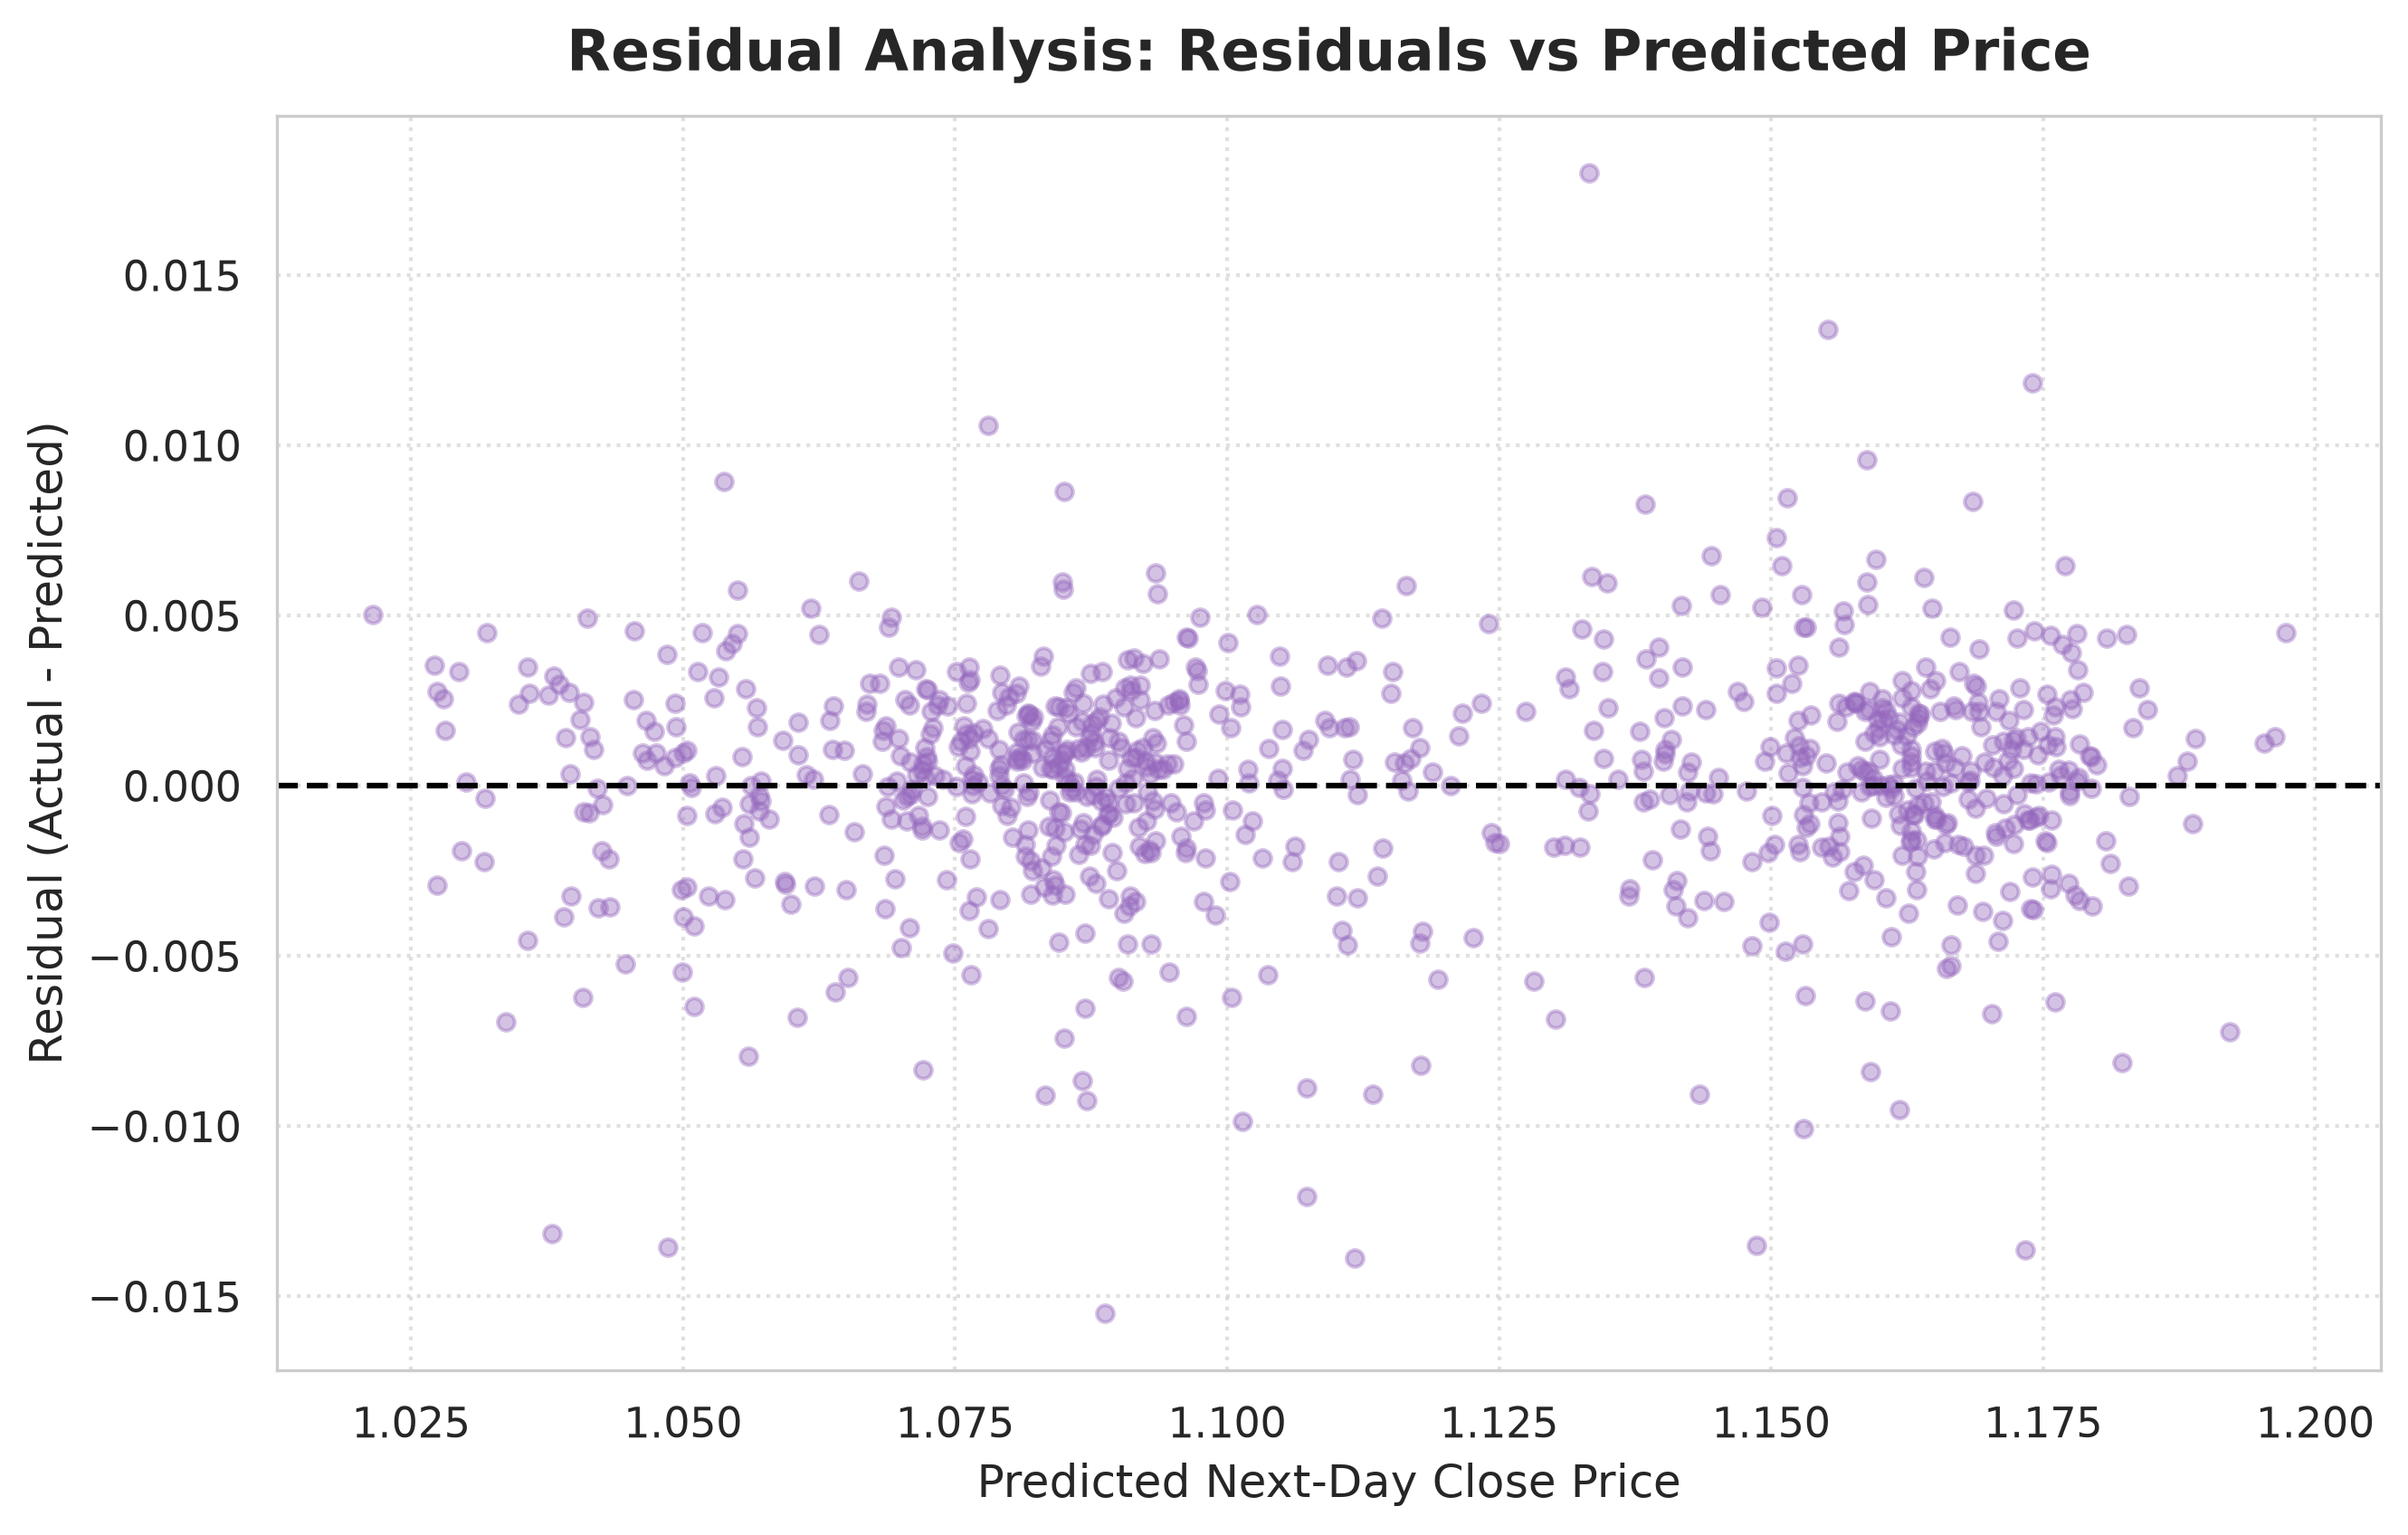

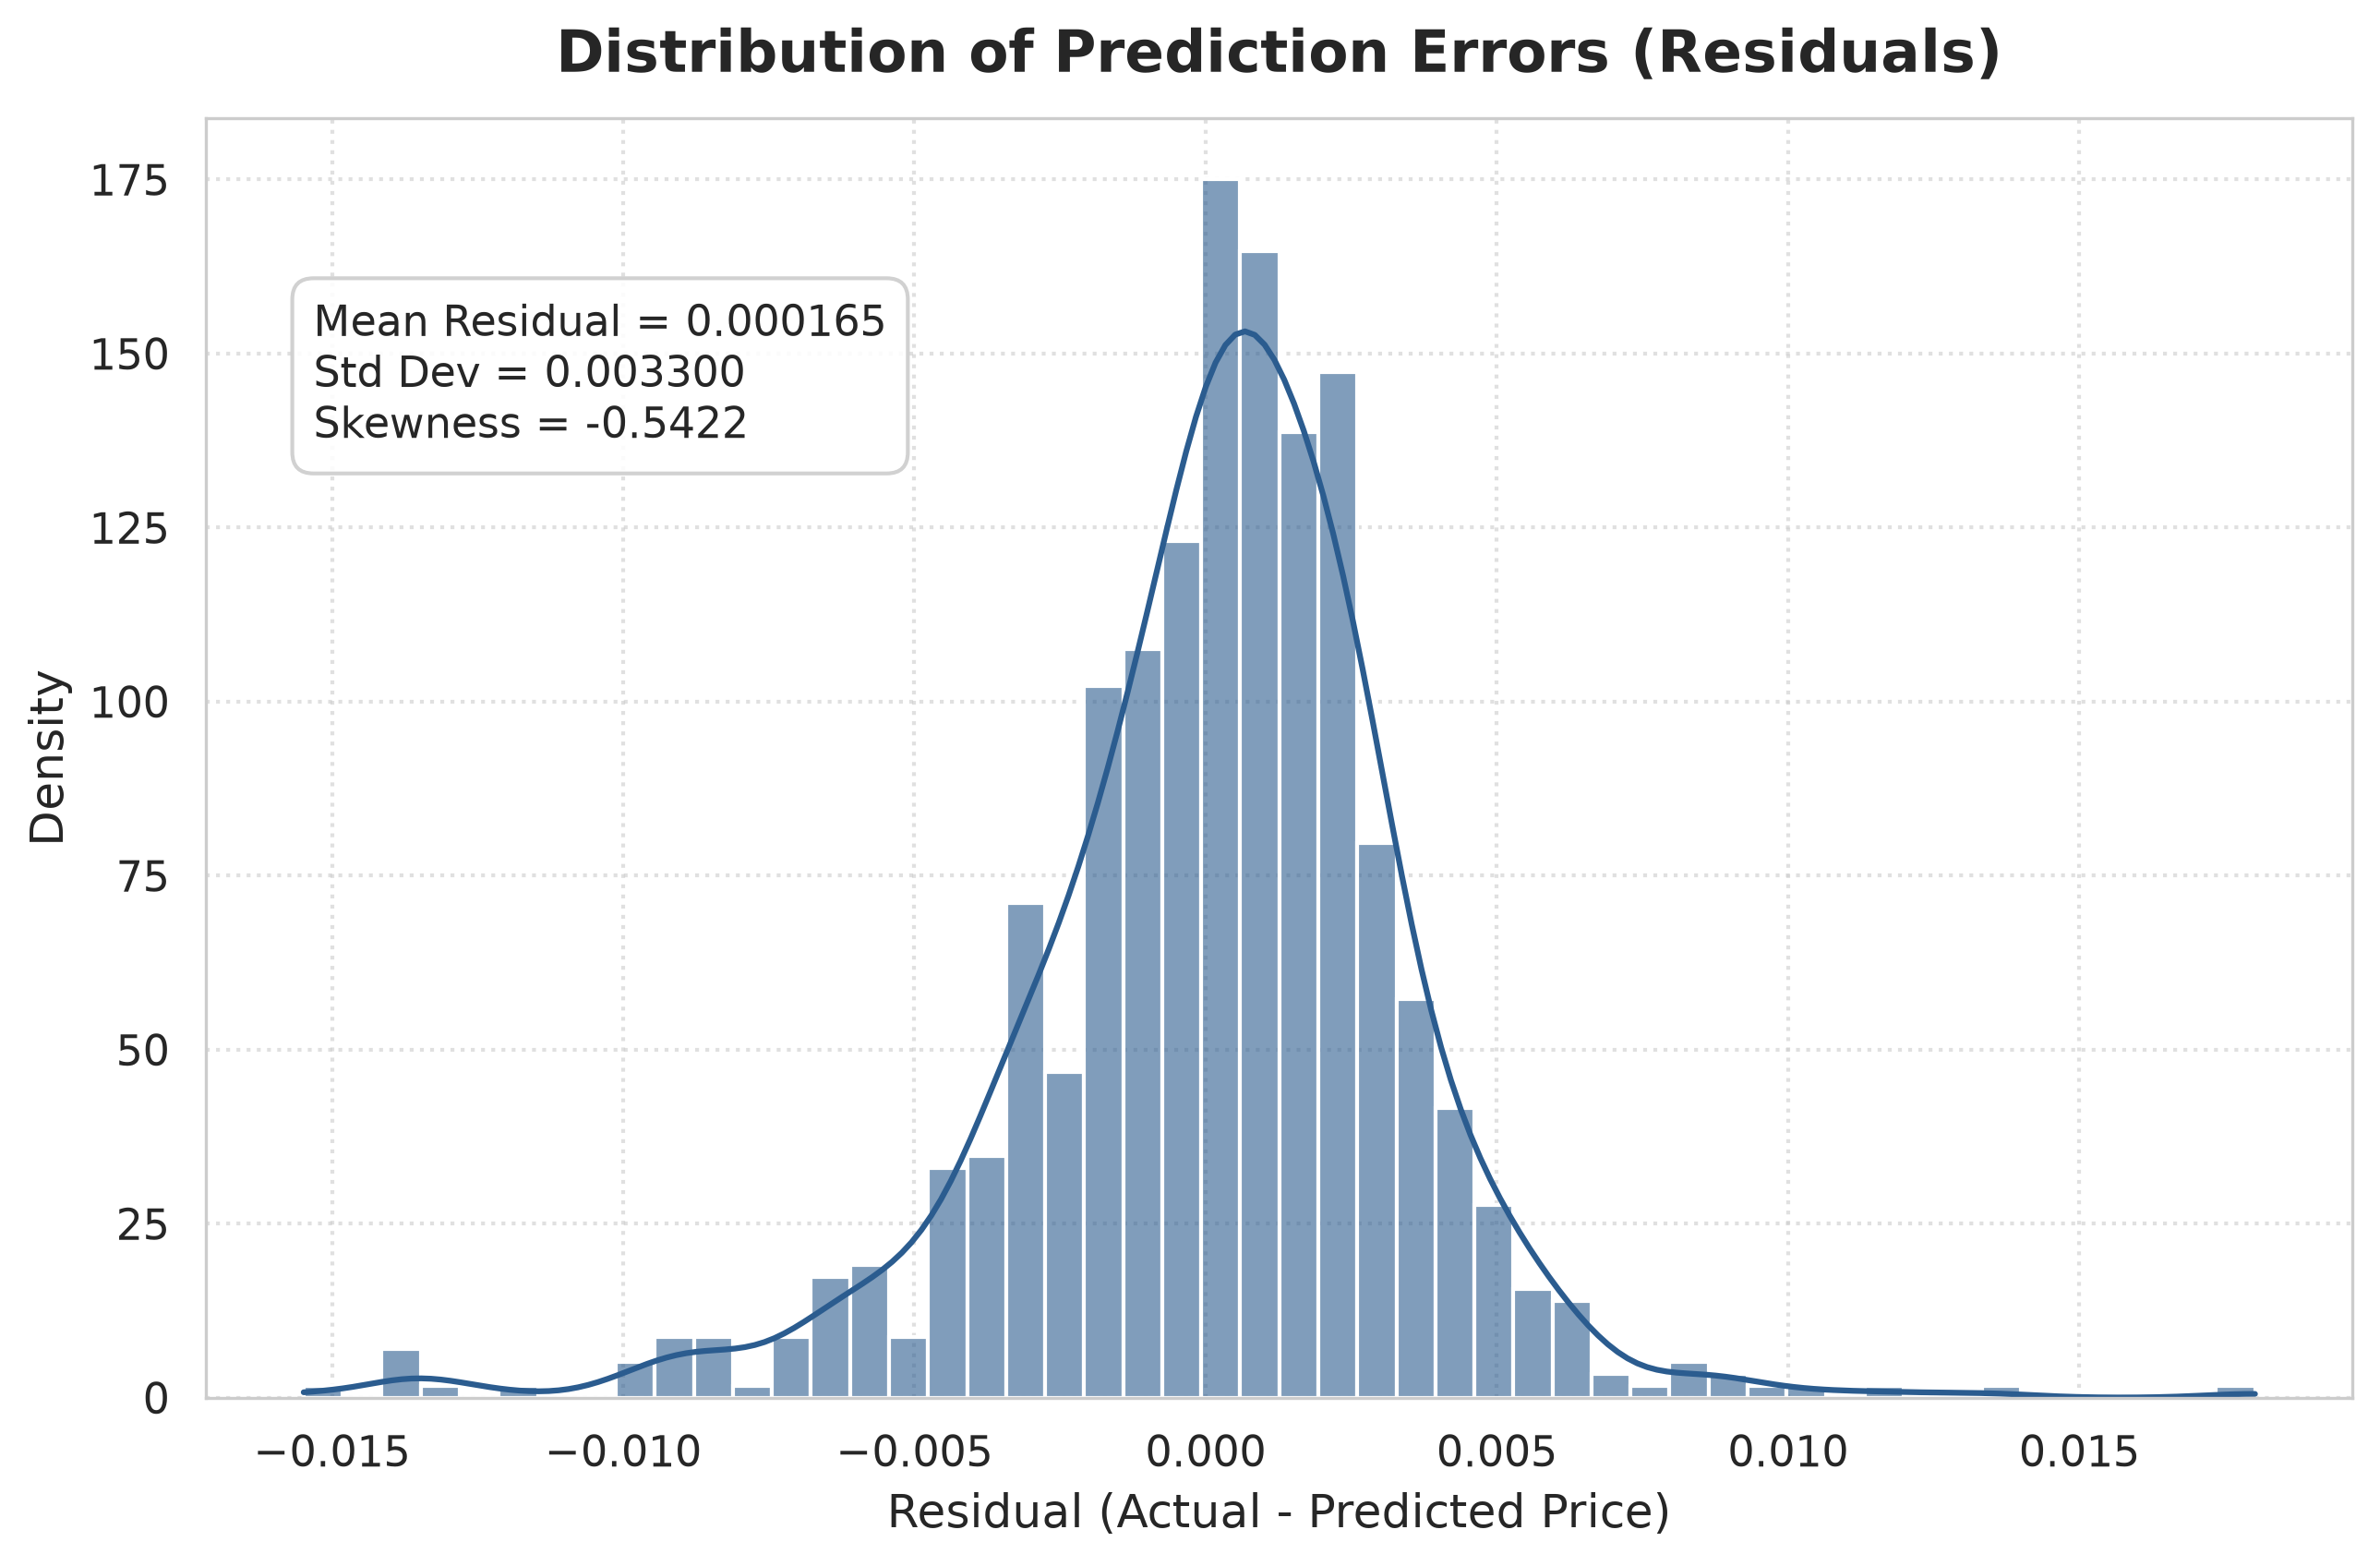

In [12]:
plot_residuals(results_df, output_dir=out_plots)
plot_residual_distribution(results_df, output_dir=out_plots)

display(Image(filename=os.path.join(out_plots, '09_residuals_vs_predicted.png')))
display(Image(filename=os.path.join(out_plots, '10_residual_distribution.png')))

## 13. Expanding Window Walk-Forward Cross Validation

In [13]:
wf_df = run_walk_forward_validation(df_clean, feature_cols, target_col, n_splits=5, min_train_pct=0.50)
display(wf_df)

,Fold,Train_Start,Train_End,Test_Start,Test_End,Train_Size,Test_Size,MAE,RMSE,R2,Directional_Accuracy_%
0,1,2010-03-11,2018-06-12,2018-06-13,2020-02-05,2150,430,0.002194,0.003096,0.978438,73.488372
1,2,2010-03-11,2020-02-05,2020-02-06,2021-09-29,2580,430,0.002538,0.003447,0.993730,76.511628
2,3,2010-03-11,2021-09-29,2021-09-30,2023-05-24,3010,430,0.003038,0.004038,0.993727,81.627907
3,4,2010-03-11,2023-05-24,2023-05-25,2025-01-16,3440,430,0.002235,0.003034,0.975521,76.046512
4,5,2010-03-11,2025-01-16,2025-01-17,2026-09-17,3870,431,0.002521,0.003543,0.991159,80.046404


## 14. Summary & Senior ML Engineer Interpretation
### Answers to Key Quantitative Analysis Questions:
1. **How well does Linear Regression predict next-day Close?**  
   The model achieves a test $R^2$ of **0.9945** and RMSE of **0.003303** ($0.21\%$ MAPE). High $R^2$ is expected because daily currency prices move continuously.
2. **Which features have the strongest coefficients?**  
   `High` (+0.0697) and `Low` (+0.0696) prices from day $t$ have the highest positive standardized impact, while `EMA_20` (-0.0192) and `Open` (-0.0170) exert dampening effects.
3. **Does the model outperform the Naive Baseline?**  
   Yes! The model reduces Test RMSE from **0.004703** (Naive Baseline) down to **0.003303** (a 29.8% error reduction) and achieves **77.93% Directional Accuracy**.